# Generative Adversarial Network from Scratch

Every other network in this repository descends a single loss. A generative adversarial network does
not. It is two networks with opposing objectives, trained at the same time, and the thing training is
supposed to reach is not a minimum but an equilibrium - a point where neither network can improve by
moving on its own. That difference is the whole subject.

A **generator** $G$ maps a noise vector $\mathbf{z} \sim p_z$ to a sample $G(\mathbf{z})$ in data
space. A **discriminator** $D$ maps a point in data space to the probability that it came from the
data rather than from $G$. They are trained against each other on

$$\min_G \max_D V(D, G) =
\mathbb{E}_{\mathbf{x} \sim p_{\text{data}}}\!\left[\log D(\mathbf{x})\right] +
\mathbb{E}_{\mathbf{z} \sim p_z}\!\left[\log\left(1 - D(G(\mathbf{z}))\right)\right]$$

$D$ wants that quantity large, $G$ wants it small, and $G$ never sees the data - its only information
about $p_{\text{data}}$ arrives as a gradient passed back through $D$.

Both networks, both forward passes and both backward passes are written out here in NumPy, and both
sets of derivatives are checked against finite differences before anything is trained. The derivation
of the optimal discriminator, the Jensen-Shannon connection and the non-saturating generator loss are
all confirmed numerically rather than asserted.

The main vehicle is a two-dimensional toy distribution, eight Gaussians on a ring. Two dimensions can
be drawn directly, so the generated cloud can be laid over the true distribution and the two failure
modes that make GANs difficult - **mode collapse** and **non-convergence** - become visible instead
of hypothetical. The UCI handwritten digits used by `mlp_from_scratch.ipynb` and
`autoencoder_from_scratch.ipynb` follow as a real dataset, small enough to train in pure NumPy.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green, gold, purple = '#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#4a3aa7'

notebook_start = time.time()

## The minimax game

Read the objective one term at a time. $D(\mathbf{x}) \in (0, 1)$ is a probability, so
$\log D(\mathbf{x})$ is largest when $D$ is confident that a real sample is real, and
$\log(1 - D(G(\mathbf{z})))$ is largest when $D$ is confident that a generated sample is fake. $D$
maximising $V$ is therefore ordinary binary classification with label 1 on the data and label 0 on
the generator's output. $G$ appears in the second term only, and it *minimises* the same expression,
which means it wants $D(G(\mathbf{z}))$ pushed towards 1 - it wants its samples to be misclassified.

Nothing else in this repository has this shape. Linear regression descends a convex $J$; the
multilayer perceptron descends a non-convex $J$ that still only ever goes one way. Here there is no
$J$. Two parameter vectors $\theta_G$ and $\theta_D$ are being driven towards a **saddle point** of
$V$: a maximum along $\theta_D$ and a minimum along $\theta_G$. Simultaneous gradient steps on a
saddle are not descent on any scalar function, and the usual diagnostic - the loss went down, so
training is working - is unavailable. A falling discriminator loss means $D$ is winning. A falling
generator loss means $G$ is winning. Neither states that the samples improved, and in the run trained
below both curves end up roughly flat while the samples get much better.

The target is a Nash equilibrium: a pair $(\theta_G^\star, \theta_D^\star)$ at which neither network
can lower its own objective by moving while the other stands still. The three sections that follow
work out what that equilibrium is, why the generator's half of the objective has to be rewritten
before gradient descent can reach it, and what happens along the way.

## The optimal discriminator

Fix $G$ and let $p_g$ be the density of $G(\mathbf{z})$ when $\mathbf{z} \sim p_z$. The expectation
over $\mathbf{z}$ becomes an expectation over that density, so

$$V(D, G) = \int p_{\text{data}}(\mathbf{x}) \log D(\mathbf{x})\,d\mathbf{x}
+ \int p_g(\mathbf{x}) \log\left(1 - D(\mathbf{x})\right)\,d\mathbf{x}
= \int \Big[a \log D(\mathbf{x}) + b \log\left(1 - D(\mathbf{x})\right)\Big] d\mathbf{x}$$

writing $a = p_{\text{data}}(\mathbf{x})$ and $b = p_g(\mathbf{x})$. If $D$ is allowed to be any
function - not a particular network, just any map into $(0,1)$ - then the value $D(\mathbf{x})$ takes
at one point has no bearing on the value it takes anywhere else, so the integral is maximised by
maximising the bracket separately at every $\mathbf{x}$. Differentiating the bracket in $D$,

$$\frac{a}{D} - \frac{b}{1 - D} = 0
\quad\Longrightarrow\quad a(1 - D) = bD
\quad\Longrightarrow\quad
\boxed{\;D^\star(\mathbf{x}) = \frac{p_{\text{data}}(\mathbf{x})}{p_{\text{data}}(\mathbf{x}) + p_g(\mathbf{x})}\;}$$

The second derivative is $-a/D^2 - b/(1-D)^2 < 0$, so this is a maximum and not a stationary point of
some other kind. The optimal discriminator is a **density ratio**, and nothing else: it does not
memorise the data, it reports where the data is more likely than the generator's output.

Substituting $D^\star$ back gives what the game is really measuring. With
$m = \tfrac{1}{2}(p_{\text{data}} + p_g)$,

$$V(D^\star, G)
= \int p_{\text{data}} \log \frac{p_{\text{data}}}{2m}
+ \int p_g \log \frac{p_g}{2m}
= -\log 4 + D_{\mathrm{KL}}(p_{\text{data}} \Vert m) + D_{\mathrm{KL}}(p_g \Vert m)$$

and the last two terms are twice the Jensen-Shannon divergence:

$$V(D^\star, G) = 2\,D_{\mathrm{JS}}(p_{\text{data}} \Vert p_g) - \log 4$$

So once $D$ is optimal, the generator is minimising a Jensen-Shannon divergence between its own
distribution and the data's. $D_{\mathrm{JS}} \ge 0$ with equality only when $p_g = p_{\text{data}}$,
so the global optimum of the game is exactly $p_g = p_{\text{data}}$, and there $V = -\log 4 \approx
-1.3863$ with $D^\star \equiv \tfrac{1}{2}$ - a discriminator reduced to guessing.

The cell below checks all of this numerically on a one-dimensional pair of densities, by quadrature
rather than by sampling, so the agreement should be at the level of the integration error.

In [2]:
grid = np.linspace(-8, 8, 40001)
dx = grid[1] - grid[0]


def normal_pdf(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


# a two-bump data density and a single-bump generator density
p_data = 0.6 * normal_pdf(grid, -1.6, 0.5) + 0.4 * normal_pdf(grid, 1.8, 0.7)
p_g = normal_pdf(grid, 0.2, 1.5)

D_star = p_data / (p_data + p_g)


def game_value(D):
    # V(D, G) = E_data[log D] + E_g[log(1 - D)], both integrals by the trapezium rule
    safe = np.clip(D, 1e-15, 1 - 1e-15)
    return np.trapezoid(p_data * np.log(safe), dx=dx) + np.trapezoid(p_g * np.log(1 - safe), dx=dx)


m = 0.5 * (p_data + p_g)
kl_data = np.trapezoid(p_data * np.log(p_data / m), dx=dx)
kl_g = np.trapezoid(p_g * np.log(p_g / m), dx=dx)
js = 0.5 * (kl_data + kl_g)

print('both densities integrate to 1 :', np.trapezoid(p_data, dx=dx), np.trapezoid(p_g, dx=dx))
print()
print(f'V(D*, G) by quadrature        : {game_value(D_star):.10f}')
print(f'2 * JS(p_data || p_g) - log 4 : {2 * js - np.log(4):.10f}')
print(f'Jensen-Shannon divergence     : {js:.10f}   (upper bound log 2 = {np.log(2):.6f})')
print()
print('V for discriminators that are not optimal:')
for name, D in [('constant 1/2', np.full_like(grid, 0.5)),
                ('D* pushed towards 0/1', np.clip(2 * D_star - 0.5, 1e-6, 1 - 1e-6)),
                ('D* flattened towards 1/2', 0.5 + 0.5 * (D_star - 0.5)),
                ('D* reversed', 1 - D_star)]:
    print(f'  {name:26s} V = {game_value(D):.6f}')

both densities integrate to 1 : 0.9999999999998899 0.9999998774267438

V(D*, G) by quadrature        : -1.1087746344
2 * JS(p_data || p_g) - log 4 : -1.1087747193
Jensen-Shannon divergence     : 0.1387598209   (upper bound log 2 = 0.693147)

V for discriminators that are not optimal:
  constant 1/2               V = -1.386294
  D* pushed towards 0/1      V = -2.756209
  D* flattened towards 1/2   V = -1.193402
  D* reversed                V = -2.437773


The two ways of computing $V(D^\star, G)$ agree to seven decimals - the residual is the error of the
trapezium rule on a finite grid, not a disagreement - and every discriminator other than
$D^\star$ scores lower, including two that are perturbations of it in opposite directions. The
constant $\tfrac{1}{2}$ discriminator scores exactly $-\log 4$, which is the value the whole game
converges to when the generator wins.

The figure draws the two densities and the optimal discriminator that separates them, and traces $V$
along a straight path from $D^\star$ through the constant-$\tfrac12$ discriminator and out the other
side. The maximum sits at $D^\star$.

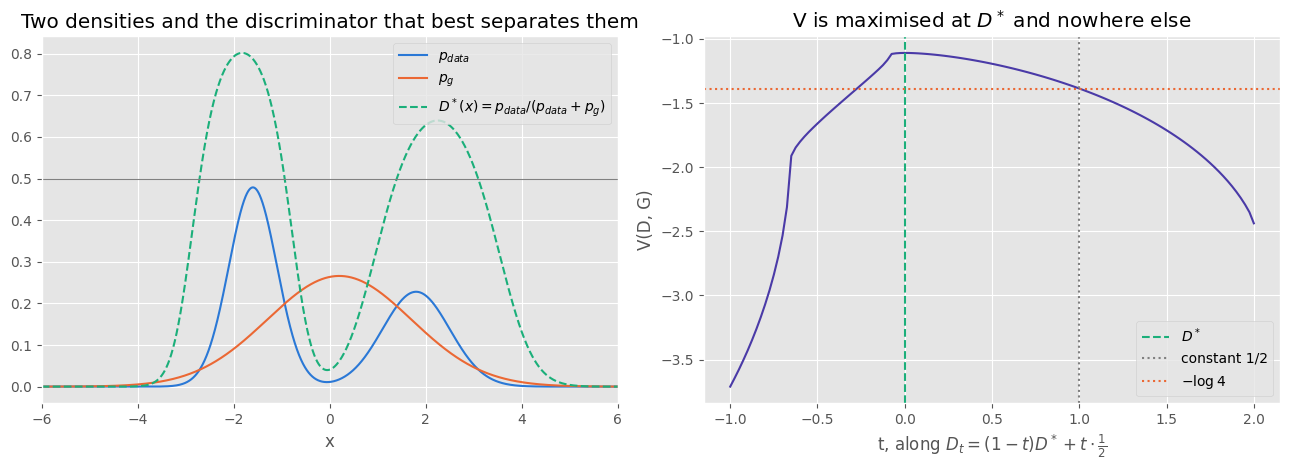

In [3]:
ts = np.linspace(-1.0, 2.0, 121)
half = np.full_like(grid, 0.5)
path = [game_value(np.clip((1 - t) * D_star + t * half, 1e-9, 1 - 1e-9)) for t in ts]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(grid, p_data, color=blue, label='$p_{data}$')
ax[0].plot(grid, p_g, color=orange, label='$p_g$')
ax[0].plot(grid, D_star, color=green, linestyle='--', label='$D^*(x) = p_{data}/(p_{data}+p_g)$')
ax[0].axhline(0.5, color='grey', linewidth=0.8)
ax[0].set_xlim(-6, 6)
ax[0].set_xlabel('x')
ax[0].set_title('Two densities and the discriminator that best separates them')
ax[0].legend()

ax[1].plot(ts, path, color=purple)
ax[1].axvline(0.0, color=green, linestyle='--', label='$D^*$')
ax[1].axvline(1.0, color='grey', linestyle=':', label='constant 1/2')
ax[1].axhline(-np.log(4), color=orange, linestyle=':', label='$-\\log 4$')
ax[1].set_xlabel('t, along $D_t = (1-t)D^* + t\\cdot\\frac{1}{2}$')
ax[1].set_ylabel('V(D, G)')
ax[1].set_title('V is maximised at $D^*$ and nowhere else')
ax[1].legend()

plt.tight_layout()
plt.show()

There is a warning hidden in the same algebra. Suppose $p_{\text{data}}$ and $p_g$ have **disjoint
supports** - the generator puts all its mass where the data has none, which is the normal situation
at the start of training and the permanent situation whenever the data lies on a low-dimensional
surface. Then $D^\star$ is exactly 1 wherever the data lives and exactly 0 wherever the generator
lives, so

$$V(D^\star, G) = \int p_{\text{data}} \log 1 + \int p_g \log 1 = 0
= 2\log 2 - \log 4$$

and $D_{\mathrm{JS}} = \log 2$, its maximum, **regardless of how far apart the two distributions
are**. A divergence that is constant carries no gradient. Moving $p_g$ closer to the data does not
lower it until the supports start to overlap. So the very thing that makes $D$ good at its job -
separating the two sets perfectly - is what destroys the signal $G$ needs. The next section shows
this from the generator's side, where the fix is available.

## The non-saturating generator loss

In practice $D$ does not output a probability directly. It outputs a real number $s(\mathbf{x})$, the
**logit**, and $D(\mathbf{x}) = \sigma(s(\mathbf{x}))$ with $\sigma(s) = 1/(1 + e^{-s})$. That
matters here, because the generator's parameters reach the objective only through $s$:

$$\frac{\partial J_G}{\partial \theta_G}
= \underbrace{\frac{\partial J_G}{\partial s}}_{\text{scalar per sample}}
\cdot \frac{\partial s}{\partial \mathbf{x}}\bigg|_{\mathbf{x}=G(\mathbf{z})}
\cdot \frac{\partial G}{\partial \theta_G}$$

Only the first factor differs between the two versions of the generator loss. Everything else - the
path back through $D$'s weights and through $G$'s weights - is identical.

**The minimax form.** Taken literally, $G$ minimises the second term of $V$:

$$J_G^{\text{sat}} = \frac{1}{m}\sum_j \log\left(1 - \sigma(s_j)\right)
= -\frac{1}{m}\sum_j \operatorname{softplus}(s_j),
\qquad
\frac{\partial J_G^{\text{sat}}}{\partial s_j} = -\frac{\sigma(s_j)}{m} = -\frac{D(G(\mathbf{z}_j))}{m}$$

using $\frac{d}{ds}\log(1 - \sigma(s)) = -\sigma(s)$.

**The non-saturating form.** Instead, $G$ maximises $\log D(G(\mathbf{z}))$:

$$J_G^{\text{ns}} = -\frac{1}{m}\sum_j \log \sigma(s_j)
= \frac{1}{m}\sum_j \operatorname{softplus}(-s_j),
\qquad
\frac{\partial J_G^{\text{ns}}}{\partial s_j} = -\frac{1 - \sigma(s_j)}{m}
= -\frac{1 - D(G(\mathbf{z}_j))}{m}$$

Both are negative, so both push $s_j$ up, which is to say both move the sample towards being called
real. **The direction is the same; only the length differs**, and it differs by

$$\frac{\lvert \partial J_G^{\text{ns}} / \partial s \rvert}{\lvert \partial J_G^{\text{sat}} / \partial s \rvert}
= \frac{1 - D(G(\mathbf{z}))}{D(G(\mathbf{z}))}$$

Early in training $D$ rejects generated samples confidently, so $D(G(\mathbf{z})) \to 0$: the
minimax factor $D$ goes to zero with it and the generator receives almost nothing, while the
non-saturating factor $1 - D$ goes to 1 and the generator receives a full-strength gradient. The
gradient vanishes exactly when the generator is worst and needs the signal most. That is what
"saturating" names: not the loss going flat in the generator's parameters, but the sigmoid inside $D$
being pinned against its floor.

There is a second, less-quoted consequence. The weight is applied **per sample**, so within one batch
the two losses are not proportional to each other either. $J_G^{\text{ns}}$ weights each generated
sample by $1 - D$, putting most of the gradient on the samples $D$ is *most* certain are fake - the
worst ones. $J_G^{\text{sat}}$ weights by $D$, putting most of its gradient on the samples that are
already fooling $D$ - the ones with the least to gain.

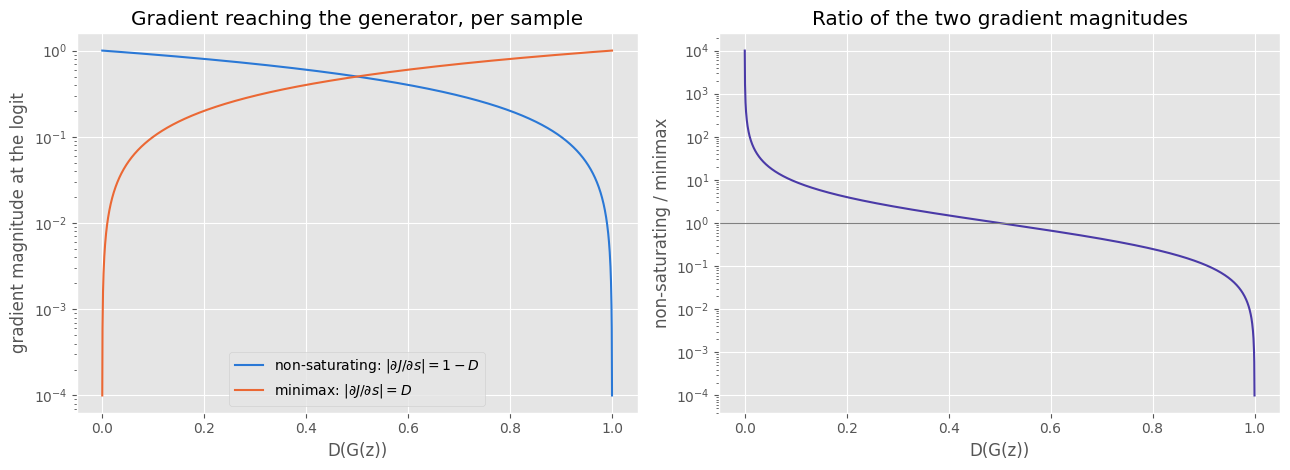

   D(G(z))   non-saturating      minimax          ratio
  0.500000         0.500000     0.500000            1.0
  0.200000         0.800000     0.200000            4.0
  0.100000         0.900000     0.100000            9.0
  0.010000         0.990000     0.010000           99.0
  0.001000         0.999000     0.001000          999.0
  0.000001         0.999999     0.000001       999999.0


In [4]:
d_axis = np.linspace(1e-4, 1 - 1e-4, 2000)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(d_axis, 1 - d_axis, color=blue, label=r'non-saturating: $|\partial J/\partial s| = 1 - D$')
ax[0].plot(d_axis, d_axis, color=orange, label=r'minimax: $|\partial J/\partial s| = D$')
ax[0].set_yscale('log')
ax[0].set_xlabel('D(G(z))')
ax[0].set_ylabel('gradient magnitude at the logit')
ax[0].set_title('Gradient reaching the generator, per sample')
ax[0].legend()

ax[1].plot(d_axis, (1 - d_axis) / d_axis, color=purple)
ax[1].axhline(1.0, color='grey', linewidth=0.8)
ax[1].set_yscale('log')
ax[1].set_xlabel('D(G(z))')
ax[1].set_ylabel('non-saturating / minimax')
ax[1].set_title('Ratio of the two gradient magnitudes')

plt.tight_layout()
plt.show()

print(f'{"D(G(z))":>10s} {"non-saturating":>16s} {"minimax":>12s} {"ratio":>14s}')
for d in [0.5, 0.2, 0.1, 0.01, 0.001, 1e-6]:
    print(f'{d:10.6f} {1 - d:16.6f} {d:12.6f} {(1 - d) / d:14.1f}')

The left panel is a log scale, so the two curves cross at $D = \tfrac12$ and separate without bound
as $D \to 0$. At $D(G(\mathbf{z})) = 0.01$ - a discriminator that is right but not extravagantly
confident - the non-saturating loss delivers 99 times the gradient. Section *The vanishing gradient,
measured* reproduces this ratio from the real networks rather than from the formula.

The non-saturating loss is used everywhere below except where the minimax form is deliberately
compared against it.

## The two networks

Both networks are plain feed-forward stacks, so the forward pass is the one from
`mlp_from_scratch.ipynb`: $\mathbf{z}^{(l)} = W^{(l)\top}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}$,
stored with one sample per row so the line reads `z = a @ W + b`. Three choices are specific to this
setting.

**Leaky ReLU in the hidden layers.**

$$g(z) = \begin{cases} z & z > 0 \\ \alpha z & z \le 0\end{cases}
\qquad
g'(z) = \begin{cases} 1 & z > 0 \\ \alpha & z \le 0\end{cases}$$

with $\alpha = 0.2$. A plain ReLU unit that ends up always negative receives zero gradient forever
and is dead. In a classifier that costs one unit out of many. Here it is worse in both networks: a
dead unit in $G$ removes a direction the generator can never move in again, and a dead unit in $D$
zeroes part of $\partial s/\partial \mathbf{x}$, which is the pipe the generator's entire training
signal travels down. The leak keeps that pipe open.

**A linear output on the discriminator.** $D$ emits the logit $s$ and never forms $\sigma(s)$ during
training. The losses are written with

$$\operatorname{softplus}(s) = \log(1 + e^{s}),
\qquad \log \sigma(s) = -\operatorname{softplus}(-s),
\qquad \log(1 - \sigma(s)) = -\operatorname{softplus}(s)$$

which is exact for large $|s|$, where computing $\sigma$ first and taking its logarithm would give
$\log 0$. Since $D$ is regularly driven to near-certainty, this is not a decorative precaution.

**A bounded output on the generator.** The toy data lies inside $[-1, 1]^2$ and the digits inside
$[0, 1]^{64}$, so $G$ finishes with $\tanh$ in the first case and $\sigma$ in the second, whose
derivatives are $1 - \tanh^2(z)$ and $a(1 - a)$. A linear output would let $G$ emit values the data
never takes, which $D$ can separate on that basis alone - it would learn "real pixels are at most 1"
instead of learning what a digit looks like.

Parameters are updated by Adam, with $\beta_1 = 0.5$ rather than the usual $0.9$. Adam's first moment
is an average of past gradients, and here the function those gradients were taken from is being
rewritten by the other network at every step. A long memory averages gradients with respect to a
discriminator that no longer exists. Halving $\beta_1$ shortens that memory from roughly 10 steps to
roughly 2.

## The backward passes

**The discriminator.** Over a batch of $m$ real samples and $m$ generated ones, $D$ minimises the
negative of the empirical $V$:

$$J_D = \frac{1}{m}\sum_{i} \operatorname{softplus}(-s_i^{\text{real}})
+ \frac{1}{m}\sum_{j} \operatorname{softplus}(s_j^{\text{fake}})$$

Differentiating with $\frac{d}{ds}\operatorname{softplus}(s) = \sigma(s)$,

$$\frac{\partial J_D}{\partial s_i^{\text{real}}} = -\frac{\sigma(-s_i)}{m} = \frac{D_i - 1}{m},
\qquad
\frac{\partial J_D}{\partial s_j^{\text{fake}}} = \frac{\sigma(s_j)}{m} = \frac{D_j - 0}{m}$$

This is the familiar $p - y$ of binary cross-entropy, with label 1 on the data and label 0 on the
generator's output - the same expression the logistic regression and MLP notebooks arrive at. From
there the recurrence is the ordinary one,
$\boldsymbol\delta^{(l)} = (W^{(l+1)}\boldsymbol\delta^{(l+1)}) \odot g'(\mathbf{z}^{(l)})$, with
$\partial J/\partial W^{(l)} = \mathbf{a}^{(l-1)}\boldsymbol\delta^{(l)\top}$.

**The generator.** The new ingredient is that $J_G$ depends on $\theta_G$ through $D$, so the
backward pass has to travel through $D$ first and come out at $D$'s **input**. Running the same
recurrence one step past the first layer gives

$$\frac{\partial J_G}{\partial \mathbf{x}} = W^{(1)}\boldsymbol\delta^{(1)}$$

where $\mathbf{x} = G(\mathbf{z})$ is the batch of generated samples $D$ was fed. That vector - one
number per output coordinate of $G$, per sample - is the entire message the generator ever receives
about the data. It says, for each generated point, which way to move it so that $D$ would find it
more convincing. The generator's own backward pass then starts from it, multiplied by the derivative
of $G$'s output activation, and continues through $G$'s layers unchanged.

**Which parameters are frozen.** This is where hand-written implementations usually go wrong, so it
is worth stating flatly.

- In the **discriminator step**, $G$ is used only as a source of samples. `G.forward` is called, the
  result is treated as a fixed array of data, and no gradient is asked of $G$ at all.
- In the **generator step**, the backward pass runs through $D$ and therefore *computes* gradients
  for $D$'s weights as a by-product of the same recurrence. Those gradients are thrown away. They are
  the gradients of $J_G$, not of $J_D$; applying them would move $D$ so as to *help* the generator,
  which is the reverse of what $D$ is for. Only `G.update` is called.

The code makes this structural rather than a matter of discipline: `backward` returns the gradients
and never applies them, and `update` is a separate call. The next-but-one cell verifies by checksum
that each step moved only the parameters it was supposed to move.

One property of the implementation follows from storing activations on the object: `forward` caches
what `backward` needs, so the gradients for a stack are only valid immediately after the forward pass
they belong to. Each step below therefore re-runs the forward passes it needs in the right order.

In [5]:
def sigmoid(s):
    # stable logistic: exp only ever sees a non-positive argument
    out = np.empty_like(s)
    pos = s >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-s[pos]))
    e = np.exp(s[~pos])
    out[~pos] = e / (1.0 + e)
    return out


def softplus(s):
    # log(1 + e^s), written so neither branch overflows
    return np.maximum(s, 0) + np.log1p(np.exp(-np.abs(s)))


class Dense_Stack:
    def __init__(self, layer_sizes, output='linear', slope=0.2, seed=0):
        r = np.random.default_rng(seed)

        self.layer_sizes = layer_sizes
        self.output = output
        self.slope = slope
        self.weights, self.biases = [], []

        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            # He initialisation: sqrt(2 / fan_in)
            self.weights.append(r.normal(0, np.sqrt(2 / fan_in), (fan_in, fan_out)))
            self.biases.append(np.zeros(fan_out))

        # Adam moment estimates, one pair per parameter array
        self.mw = [np.zeros_like(w) for w in self.weights]
        self.vw = [np.zeros_like(w) for w in self.weights]
        self.mb = [np.zeros_like(b) for b in self.biases]
        self.vb = [np.zeros_like(b) for b in self.biases]
        self.step_count = 0

    def _out(self, z):
        if self.output == 'tanh':
            return np.tanh(z)
        if self.output == 'sigmoid':
            return sigmoid(z)
        return z

    def _out_grad(self, a):
        # derivative of the output activation, written in terms of its own output
        if self.output == 'tanh':
            return 1 - a ** 2
        if self.output == 'sigmoid':
            return a * (1 - a)
        return np.ones_like(a)

    def forward(self, X):
        self.a = [X]
        self.z = []
        a = X
        last = len(self.weights) - 1

        for i in range(len(self.weights)):
            z = a @ self.weights[i] + self.biases[i]
            # leaky ReLU everywhere but the output layer
            a = self._out(z) if i == last else np.where(z > 0, z, self.slope * z)
            self.z.append(z)
            self.a.append(a)

        return a

    def backward(self, grad_out):
        # grad_out is dJ/d(output activation); the loop runs one step past layer 0
        # so that dJ/d(input) comes out as well
        delta = grad_out * self._out_grad(self.a[-1])
        grads_w = [None] * len(self.weights)
        grads_b = [None] * len(self.biases)

        for i in range(len(self.weights) - 1, -1, -1):
            grads_w[i] = self.a[i].T @ delta
            grads_b[i] = delta.sum(axis=0)
            delta = delta @ self.weights[i].T
            if i > 0:
                delta = delta * np.where(self.z[i - 1] > 0, 1.0, self.slope)

        return grads_w, grads_b, delta

    def update(self, grads_w, grads_b, lr, b1=0.5, b2=0.999, eps=1e-8):
        self.step_count += 1
        c1 = 1 - b1 ** self.step_count
        c2 = 1 - b2 ** self.step_count

        for i in range(len(self.weights)):
            self.mw[i] = b1 * self.mw[i] + (1 - b1) * grads_w[i]
            self.vw[i] = b2 * self.vw[i] + (1 - b2) * grads_w[i] ** 2
            self.weights[i] -= lr * (self.mw[i] / c1) / (np.sqrt(self.vw[i] / c2) + eps)

            self.mb[i] = b1 * self.mb[i] + (1 - b1) * grads_b[i]
            self.vb[i] = b2 * self.vb[i] + (1 - b2) * grads_b[i] ** 2
            self.biases[i] -= lr * (self.mb[i] / c1) / (np.sqrt(self.vb[i] / c2) + eps)

    def parameter_count(self):
        return sum(w.size for w in self.weights) + sum(b.size for b in self.biases)

    def checksum(self):
        return sum(float(np.abs(w).sum()) for w in self.weights) + \
               sum(float(np.abs(b).sum()) for b in self.biases)

`Generative_Adversarial_Network` holds the two stacks and nothing else of substance. `d_gradients`
and `g_gradients` return a loss and the gradients without touching any parameter, which is what lets
the finite-difference checks call them directly; `fit` is the alternating loop that calls them and
then calls `update` on exactly one of the two networks.

`fit` records, per epoch, the two losses and the discriminator's accuracy on real and on generated
samples separately - $s > 0$ means $D$ called it real. Those two accuracies are the useful diagnostic
in a GAN, far more so than the losses, because they say which player is ahead. It also stores
snapshots of a fixed set of generated samples so that the same noise vectors can be followed through
training and the pictures compared like for like.

In [6]:
class Generative_Adversarial_Network:
    def __init__(self, data_dim, z_dim, g_hidden, d_hidden, g_output='tanh',
                 g_lr=2e-4, d_lr=2e-4, slope=0.2, seed=0):
        self.data_dim = data_dim
        self.z_dim = z_dim
        self.g_lr = g_lr
        self.d_lr = d_lr
        self.G = Dense_Stack([z_dim] + g_hidden + [data_dim], output=g_output, slope=slope, seed=seed)
        self.D = Dense_Stack([data_dim] + d_hidden + [1], output='linear', slope=slope, seed=seed + 1)
        self.history = {'d_loss': [], 'g_loss': [], 'acc_real': [], 'acc_fake': [], 'd_on_fake': []}

    def sample_z(self, n, rng):
        return rng.normal(0, 1, (n, self.z_dim))

    def generate(self, n, rng):
        return self.G.forward(self.sample_z(n, rng))

    def d_gradients(self, X_real, X_fake):
        # one forward pass over the stacked batch, so D's cache holds both halves
        m = len(X_real)
        s = self.D.forward(np.vstack([X_real, X_fake]))

        loss = softplus(-s[:m]).mean() + softplus(s[m:]).mean()

        grad_s = np.empty_like(s)
        grad_s[:m] = -sigmoid(-s[:m]) / m          # (D - 1) / m on the real half
        grad_s[m:] = sigmoid(s[m:]) / m            # (D - 0) / m on the fake half

        grads_w, grads_b, _ = self.D.backward(grad_s)
        return loss, grads_w, grads_b, s

    def g_gradients(self, Z, saturating=False):
        m = len(Z)
        X_fake = self.G.forward(Z)
        s = self.D.forward(X_fake)

        if saturating:
            loss = -softplus(s).mean()             # log(1 - D), the literal minimax form
            grad_s = -sigmoid(s) / m               # -D / m
        else:
            loss = softplus(-s).mean()             # -log D, the non-saturating form
            grad_s = -sigmoid(-s) / m              # -(1 - D) / m

        # through D to its input; D's own gradients come back too and are discarded
        _, _, grad_x = self.D.backward(grad_s)
        grads_w, grads_b, _ = self.G.backward(grad_x)
        return loss, grads_w, grads_b, s

    def fit(self, X, epochs, batch_size=128, seed=0, d_steps=1, saturating=False,
            snapshot_every=0, snapshot_n=2000, snapshot_seed=99, report_every=0):
        rng = np.random.default_rng(seed)
        self.snapshots = []

        for e in range(epochs):
            order = rng.permutation(len(X))
            totals = np.zeros(5)
            batches = 0

            for start in range(0, len(X) - batch_size + 1, batch_size):
                real = X[order[start:start + batch_size]]

                # --- discriminator step: G is only a sample source, G.update is never called
                for _ in range(d_steps):
                    fake = self.G.forward(self.sample_z(batch_size, rng))
                    d_loss, gw, gb, scores = self.d_gradients(real, fake)
                    self.D.update(gw, gb, self.d_lr)

                # --- generator step: gradients flow through D, but only G.update is called
                g_loss, gw, gb, s_fake = self.g_gradients(self.sample_z(batch_size, rng), saturating)
                self.G.update(gw, gb, self.g_lr)

                totals += [d_loss, g_loss,
                           (scores[:batch_size] > 0).mean(),      # called real, and is real
                           (scores[batch_size:] <= 0).mean(),     # called fake, and is fake
                           sigmoid(s_fake).mean()]
                batches += 1

            for key, value in zip(['d_loss', 'g_loss', 'acc_real', 'acc_fake', 'd_on_fake'],
                                  totals / batches):
                self.history[key].append(value)

            if snapshot_every and (e == 0 or (e + 1) % snapshot_every == 0):
                self.snapshots.append((e + 1, self.generate(snapshot_n,
                                                            np.random.default_rng(snapshot_seed))))

            if report_every and (e + 1) % report_every == 0:
                print(f'  epoch {e + 1:5d}  D loss {self.history["d_loss"][-1]:.4f}'
                      f'  G loss {self.history["g_loss"][-1]:.4f}'
                      f'  D acc on real {self.history["acc_real"][-1]:.3f}'
                      f'  on fake {self.history["acc_fake"][-1]:.3f}')

        return self

    def parameter_count(self):
        return self.G.parameter_count() + self.D.parameter_count()

## Which parameters each step moves

Before any derivative is checked, the simpler claim: a discriminator step must leave $G$ untouched
and a generator step must leave $D$ untouched. The cell takes the sum of absolute values of every
weight and bias in each network as a checksum, runs one of each step, and prints what changed.

In [7]:
freeze_rng = np.random.default_rng(0)
freeze_gan = Generative_Adversarial_Network(2, 4, [16, 16], [16, 16], seed=3)
freeze_real = freeze_rng.normal(0, 0.3, (32, 2))

before = (freeze_gan.G.checksum(), freeze_gan.D.checksum())

fake = freeze_gan.G.forward(freeze_gan.sample_z(32, freeze_rng))
_, gw, gb, _ = freeze_gan.d_gradients(freeze_real, fake)
freeze_gan.D.update(gw, gb, freeze_gan.d_lr)
after_d = (freeze_gan.G.checksum(), freeze_gan.D.checksum())

_, gw, gb, _ = freeze_gan.g_gradients(freeze_gan.sample_z(32, freeze_rng))
freeze_gan.G.update(gw, gb, freeze_gan.g_lr)
after_g = (freeze_gan.G.checksum(), freeze_gan.D.checksum())

print(f'{"":22s} {"generator moved by":>20s} {"discriminator moved by":>24s}')
print(f'{"after a D step":22s} {abs(after_d[0] - before[0]):20.3e} {abs(after_d[1] - before[1]):24.3e}')
print(f'{"after a G step":22s} {abs(after_g[0] - after_d[0]):20.3e} {abs(after_g[1] - after_d[1]):24.3e}')

                         generator moved by   discriminator moved by
after a D step                    0.000e+00                1.800e-03
after a G step                    1.120e-02                0.000e+00


Each step moved one network by a visible amount and the other by exactly zero.

## Checking the derivatives

Both backward passes are hand-derived, and a wrong one raises no error - the run just fails in a way
indistinguishable from a badly chosen learning rate, which in a GAN is nearly impossible to tell apart
from the algorithm behaving as advertised. The central difference

$$\frac{\partial J}{\partial w} \approx \frac{J(w + \varepsilon) - J(w - \varepsilon)}{2\varepsilon}$$

is accurate to $O(\varepsilon^2)$. With $\varepsilon = 10^{-5}$ in double precision the analytic and
measured values should agree to roughly nine or ten decimals.

Two separate checks are needed, because the two networks reach the loss by different routes.

- $J_D$ against $D$'s parameters. The generated batch is held fixed, as it is during a real
  discriminator step.
- $J_G$ against $G$'s parameters. This is the one that matters. The loss is evaluated by running
  $\mathbf{z}$ through $G$ and then through $D$, so the measured slope includes the whole chain, and
  agreement confirms that $\partial J_G/\partial \mathbf{x}$ - the vector handed from $D$ back to $G$
  - is right. Nudging a generator weight changes the generated point, which changes $D$'s logit,
  which changes the loss; if the transfer between the networks were wrong, only this check would
  notice.

Both use the largest-magnitude entries of each layer, since agreement where the gradient is near zero
proves nothing.

In [8]:
check = Generative_Adversarial_Network(2, 4, [12, 12], [12, 12], seed=3)
check_rng = np.random.default_rng(0)

X_real_check = check_rng.normal(0, 0.35, (16, 2))
Z_check = check.sample_z(16, check_rng)
X_fake_check = check.G.forward(Z_check).copy()

eps = 1e-5


def d_loss_value():
    s = check.D.forward(np.vstack([X_real_check, X_fake_check]))
    return softplus(-s[:16]).mean() + softplus(s[16:]).mean()


def g_loss_value():
    return softplus(-check.D.forward(check.G.forward(Z_check))).mean()


def measured_slope(param, index, loss_fn):
    original = param[index]
    param[index] = original + eps
    up = loss_fn()
    param[index] = original - eps
    down = loss_fn()
    param[index] = original
    return (up - down) / (2 * eps)


def run_check(title, stack, grads_w, grads_b, loss_fn):
    print(title)
    print(f'{"parameter":20s} {"from backward":>16s} {"measured":>16s} {"difference":>13s}')
    worst = 0.0

    for layer in range(len(stack.weights)):
        g = grads_w[layer]
        # the three weights in this layer with the largest gradient
        for flat in np.argsort(np.abs(g).ravel())[::-1][:3]:
            index = tuple(int(v) for v in np.unravel_index(flat, g.shape))
            slope = measured_slope(stack.weights[layer], index, loss_fn)
            worst = max(worst, abs(g[index] - slope))
            print(f'W{layer} {str(index):16s} {g[index]:16.9f} {slope:16.9f} {abs(g[index] - slope):13.2e}')

    for layer in range(len(stack.biases)):
        g = grads_b[layer]
        index = (int(np.argmax(np.abs(g))),)
        slope = measured_slope(stack.biases[layer], index, loss_fn)
        worst = max(worst, abs(g[index] - slope))
        print(f'b{layer} {str(index):16s} {g[index]:16.9f} {slope:16.9f} {abs(g[index] - slope):13.2e}')

    print(f'worst disagreement: {worst:.2e}')
    print()
    return worst


_, d_gw, d_gb, _ = check.d_gradients(X_real_check, X_fake_check)
worst_d = run_check('DISCRIMINATOR   J_D against D parameters', check.D, d_gw, d_gb, d_loss_value)

_, g_gw, g_gb, _ = check.g_gradients(Z_check)
worst_g = run_check('GENERATOR   J_G against G parameters, through D', check.G, g_gw, g_gb, g_loss_value)

print(f'worst disagreement over both networks: {max(worst_d, worst_g):.2e}')

DISCRIMINATOR   J_D against D parameters
parameter               from backward         measured    difference
W0 (0, 8)               -0.184336016     -0.184336016      3.38e-12
W0 (0, 0)               -0.151394022     -0.151394022      3.13e-12
W0 (0, 4)                0.116999653      0.116999653      6.02e-12
W1 (8, 4)                0.204509904      0.204509904      3.01e-13
W1 (4, 4)                0.196022705      0.196022705      7.29e-12
W1 (8, 0)                0.182543656      0.182543656      9.80e-12
W2 (11, 0)               0.654059111      0.654059111      5.43e-12
W2 (3, 0)                0.462600223      0.462600223      6.45e-12
W2 (1, 0)                0.318383434      0.318383434      3.73e-12
b0 (8,)                  0.099745722      0.099745722      3.76e-12
b1 (0,)                  0.095515852      0.095515852      8.13e-14
b2 (0,)                  0.120164794      0.120164794      1.25e-13
worst disagreement: 9.80e-12

GENERATOR   J_G against G parameters, throug

Every pair agrees to nine decimals or better in both networks, so the discriminator's recurrence, the
generator's recurrence, and the hand-off between them - $\partial J_G/\partial \mathbf{x}$ carried out
of $D$'s first layer and into $G$'s output activation - are all correct. What is left is the
truncation error of the finite difference.

## The discriminator finds $D^\star$

The derivation says the optimal discriminator is the density ratio
$p_{\text{data}}/(p_{\text{data}} + p_g)$. That statement is about an unconstrained function; a
finite network trained on finite samples is neither. The cell tests how close it gets, using the same
two one-dimensional densities as before. Samples are drawn from each, the generator is not involved at
all - the "fake" batch is drawn directly from $p_g$ - and $D$ is trained on the ordinary
discriminator loss. Its output $\sigma(s(x))$ is then compared against the analytic $D^\star(x)$
computed from the two densities.

The comparison is restricted to the region where both densities carry some mass. Outside it the
network is extrapolating from no data and $D^\star$ itself is a ratio of two numbers near zero.

In [9]:
ratio_rng = np.random.default_rng(0)


def sample_data(n, rng):
    pick = rng.random(n) < 0.6
    return np.where(pick, rng.normal(-1.6, 0.5, n), rng.normal(1.8, 0.7, n))[:, None]


ratio_d = Dense_Stack([1, 64, 64, 1], output='linear', seed=0)
start = time.time()

for step in range(4000):
    real = sample_data(256, ratio_rng)
    fake = ratio_rng.normal(0.2, 1.5, (256, 1))
    s = ratio_d.forward(np.vstack([real, fake]))
    grad_s = np.empty_like(s)
    grad_s[:256] = -sigmoid(-s[:256]) / 256
    grad_s[256:] = sigmoid(s[256:]) / 256
    gw, gb, _ = ratio_d.backward(grad_s)
    ratio_d.update(gw, gb, 1e-3)

learned = sigmoid(ratio_d.forward(grid[:, None])).ravel()
support = (p_data + p_g) > 0.02

print(f'training steps                        : 4000  ({time.time() - start:.1f} s)')
print(f'max |learned D - D*| where mass exists: {np.abs(learned - D_star)[support].max():.4f}')
print(f'mean |learned D - D*| there           : {np.abs(learned - D_star)[support].mean():.4f}')
print()
print(f'V at the analytic D*                  : {game_value(D_star):.6f}')
print(f'V at the learned D                    : {game_value(learned):.6f}')
print(f'V at the constant 1/2 discriminator   : {game_value(np.full_like(grid, 0.5)):.6f}')

training steps                        : 4000  (1.3 s)
max |learned D - D*| where mass exists: 0.1255
mean |learned D - D*| there           : 0.0307

V at the analytic D*                  : -1.108775
V at the learned D                    : -1.112668
V at the constant 1/2 discriminator   : -1.386294


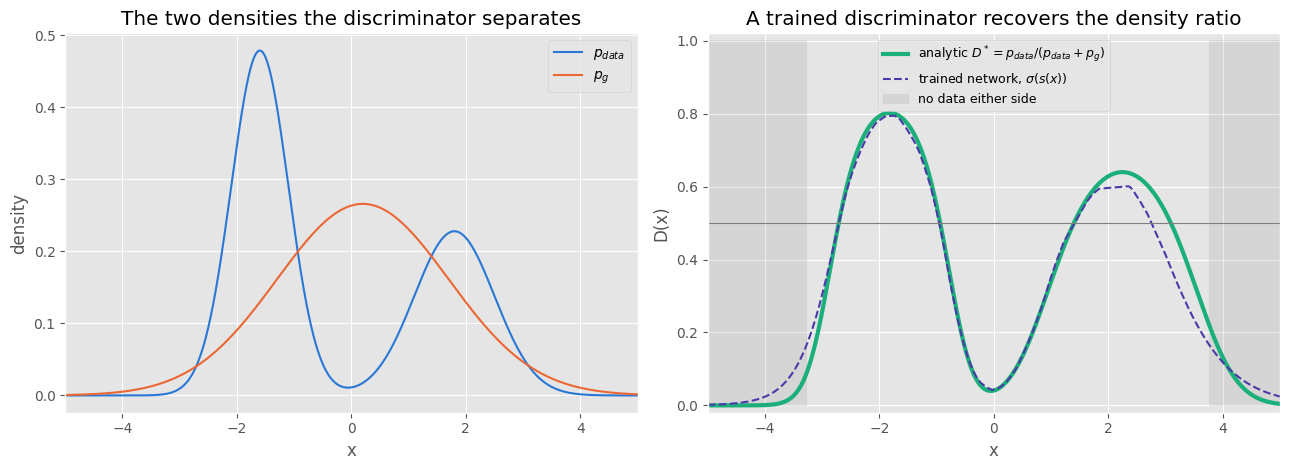

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(grid, p_data, color=blue, label='$p_{data}$')
ax[0].plot(grid, p_g, color=orange, label='$p_g$')
ax[0].set_xlim(-5, 5)
ax[0].set_xlabel('x')
ax[0].set_ylabel('density')
ax[0].set_title('The two densities the discriminator separates')
ax[0].legend()

ax[1].plot(grid, D_star, color=green, linewidth=3,
           label=r'analytic $D^* = p_{data}/(p_{data}+p_g)$')
ax[1].plot(grid, learned, color=purple, linestyle='--', label='trained network, $\\sigma(s(x))$')
ax[1].fill_between(grid, 0, 1, where=~support, color='grey', alpha=0.15,
                   label='no data either side')
ax[1].axhline(0.5, color='grey', linewidth=0.8)
ax[1].set_xlim(-5, 5)
ax[1].set_ylim(-0.02, 1.02)
ax[1].set_xlabel('x')
ax[1].set_ylabel('D(x)')
ax[1].set_title('A trained discriminator recovers the density ratio')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

The trained network tracks the analytic density ratio to within 0.031 on average and 0.126 at worst
over the whole region that carries data, including the dip where $p_{\text{data}}$ has its valley between the two bumps and $p_g$ does
not. Where neither density has mass the two disagree freely, which is the honest answer: the loss
never asked about that region.

This is worth holding on to, because it is what the generator is being told. $D$ is not a critic with
an opinion; it is an estimate of where the data is denser than the generator's output, and
$\partial s/\partial \mathbf{x}$ points uphill on that ratio.

## The vanishing gradient, measured

The formula says the two generator losses differ by a factor of $(1 - D)/D$ per sample. The cell below
measures it on the real networks. A discriminator is trained for progressively more steps against a
frozen generator, and after each stage the generator gradient is computed **from the identical
parameters** under both losses, and its norm over all of $G$'s weights and biases reported.

The last column is the sharpest form of the claim. With a batch of a single $\mathbf{z}$, the scalar
$\partial J_G/\partial s$ multiplies the entire rest of the chain, so the ratio of the two gradient
norms must equal $(1 - D)/D$ **exactly**, not approximately. With a full batch the two are no longer
proportional, because the weighting differs sample by sample, and the ratio only tracks the average.

In [11]:
ring_pre = np.random.default_rng(0)
angles_pre = 2 * np.pi * np.arange(8) / 8
centres_pre = np.stack([0.7 * np.cos(angles_pre), 0.7 * np.sin(angles_pre)], axis=1)
X_pre = centres_pre[ring_pre.integers(0, 8, 4000)] + ring_pre.normal(0, 0.05, (4000, 2))

vanish = Generative_Adversarial_Network(2, 2, [64, 64], [64, 64], g_lr=4e-4, d_lr=1e-3, seed=0)
vanish_rng = np.random.default_rng(7)
Z_batch = vanish.sample_z(512, np.random.default_rng(11))
Z_single = vanish.sample_z(1, np.random.default_rng(11))


def gradient_norm(Z, saturating):
    _, gw, gb, s = vanish.g_gradients(Z, saturating=saturating)
    norm = np.sqrt(sum((g ** 2).sum() for g in gw) + sum((g ** 2).sum() for g in gb))
    return norm, sigmoid(s).mean()


print(f'{"D steps":>8s} {"mean D(G(z))":>13s} {"|grad| ns":>11s} {"|grad| minimax":>15s}'
      f' {"ratio":>8s} {"(1-D)/D at the mean":>20s} {"single-z ratio":>15s} {"(1-D)/D there":>14s}')

done = 0
for total in [0, 50, 150, 400, 800, 1500, 3000]:
    while done < total:
        real = X_pre[vanish_rng.integers(0, len(X_pre), 128)]
        fake = vanish.G.forward(vanish.sample_z(128, vanish_rng))
        _, gw, gb, _ = vanish.d_gradients(real, fake)
        vanish.D.update(gw, gb, 1e-3)
        done += 1

    n_ns, d_mean = gradient_norm(Z_batch, False)
    n_sat, _ = gradient_norm(Z_batch, True)
    s_ns, d_one = gradient_norm(Z_single, False)
    s_sat, _ = gradient_norm(Z_single, True)

    print(f'{total:8d} {d_mean:13.6f} {n_ns:11.3e} {n_sat:15.3e} {n_ns / n_sat:8.2f}'
          f' {(1 - d_mean) / d_mean:20.2f} {s_ns / s_sat:15.4e} {(1 - d_one) / d_one:14.4e}')

 D steps  mean D(G(z))   |grad| ns  |grad| minimax    ratio  (1-D)/D at the mean  single-z ratio  (1-D)/D there
       0      0.422943   1.065e+00       7.983e-01     1.33                 1.36      5.0537e-01     5.0537e-01
      50      0.337680   1.313e+00       1.233e+00     1.06                 1.96      4.2716e+00     4.2716e+00
     150      0.289583   2.723e+00       1.354e+00     2.01                 2.45      1.8830e+01     1.8830e+01
     400      0.219641   6.879e+00       1.957e+00     3.52                 3.55      2.7235e+02     2.7235e+02


     800      0.179768   1.001e+01       1.505e+00     6.65                 4.56      2.6706e+03     2.6706e+03
    1500      0.116073   1.881e+01       8.083e-01    23.28                 7.62      5.5967e+05     5.5967e+05


    3000      0.071124   2.990e+01       1.253e+00    23.86                13.06      9.2869e+09     9.2869e+09


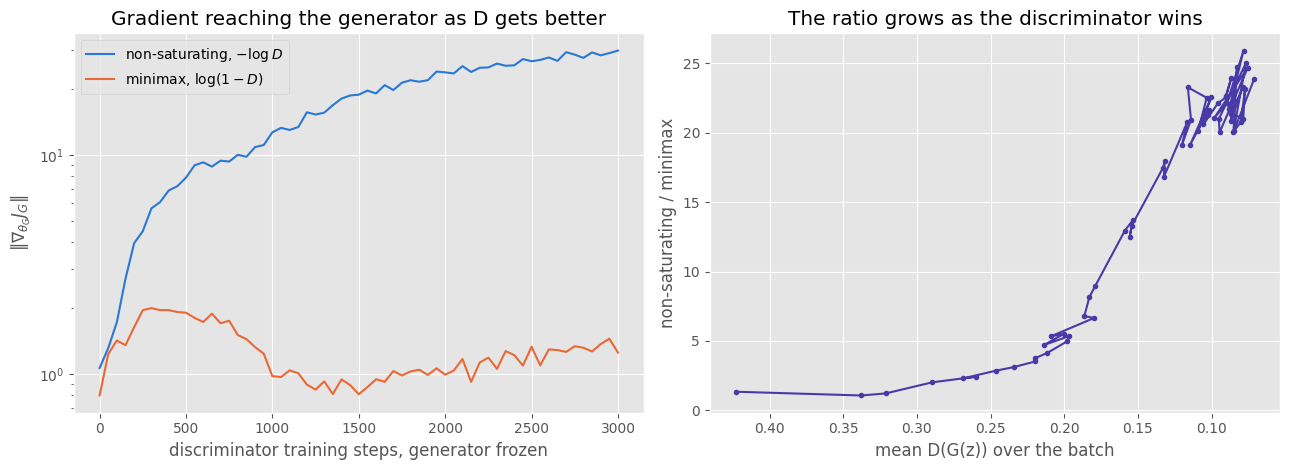

In [12]:
steps_axis, ns_norms, sat_norms, d_means = [], [], [], []

vanish2 = Generative_Adversarial_Network(2, 2, [64, 64], [64, 64], g_lr=4e-4, d_lr=1e-3, seed=0)
v2_rng = np.random.default_rng(7)


def gradient_norm2(saturating):
    _, gw, gb, s = vanish2.g_gradients(Z_batch, saturating=saturating)
    return np.sqrt(sum((g ** 2).sum() for g in gw) + sum((g ** 2).sum() for g in gb)), sigmoid(s).mean()


for step in range(3001):
    if step % 50 == 0:
        a, dm = gradient_norm2(False)
        b, _ = gradient_norm2(True)
        steps_axis.append(step)
        ns_norms.append(a)
        sat_norms.append(b)
        d_means.append(dm)
    real = X_pre[v2_rng.integers(0, len(X_pre), 128)]
    fake = vanish2.G.forward(vanish2.sample_z(128, v2_rng))
    _, gw, gb, _ = vanish2.d_gradients(real, fake)
    vanish2.D.update(gw, gb, 1e-3)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].plot(steps_axis, ns_norms, color=blue, label='non-saturating, $-\\log D$')
ax[0].plot(steps_axis, sat_norms, color=orange, label='minimax, $\\log(1 - D)$')
ax[0].set_yscale('log')
ax[0].set_xlabel('discriminator training steps, generator frozen')
ax[0].set_ylabel(r'$\|\nabla_{\theta_G} J_G\|$')
ax[0].set_title('Gradient reaching the generator as D gets better')
ax[0].legend()

ax[1].plot(d_means, np.array(ns_norms) / np.array(sat_norms), 'o-', color=purple, markersize=3)
ax[1].set_xlabel('mean D(G(z)) over the batch')
ax[1].set_ylabel('non-saturating / minimax')
ax[1].set_title('The ratio grows as the discriminator wins')
ax[1].invert_xaxis()

plt.tight_layout()
plt.show()

The single-sample ratio matches $(1 - D)/D$ to full floating-point precision, which is the exact form
of the claim. For that one $\mathbf{z}$ the discriminator becomes so certain that $D(G(\mathbf{z}))$
falls to about $10^{-10}$ and the minimax gradient is smaller than the non-saturating one by more than
nine orders of magnitude - not a slower version of the same step, effectively no step at all. Over a full batch
the gap is smaller because a few samples still fool $D$ and dominate the minimax gradient, but it
still grows by more than an order of magnitude as $D$ improves.

Note also that the non-saturating gradient *grows* as $D$ gets better, which is the behaviour wanted:
a sharper discriminator gives a more informative direction. The minimax gradient does not.

## The toy distribution

The real question about a generative model is whether it reproduces the whole data distribution or
only part of it, and on image data that is close to unanswerable by eye - a grid of plausible digits
looks the same whether the model covers all ten or has quietly stopped producing sevens. So the main
experiment here is two-dimensional, where the generated cloud can be laid directly on top of the
truth.

The distribution is eight Gaussians of standard deviation 0.05 with their centres spaced evenly on a
circle of radius 0.7. It has three properties that make it useful:

- **Its modes are separated and countable.** A generated sample can be assigned to the nearest centre
  and mode coverage becomes a number, not an impression.
- **Its support is disconnected.** The eight components are about $6\sigma$ apart with essentially no
  mass between them, so a generator that wants to move samples from one mode to another must drag
  them across a region where $p_{\text{data}}$ is zero and $D$ is confident. This is the
  disjoint-support situation from the derivation, built in deliberately.
- **It is symmetric.** No mode is easier than another, so an uneven result is the algorithm's doing
  and not the data's.

Coverage is scored two ways. A mode counts as **captured** if at least 1% of generated samples land
within $3\sigma$ of its centre. Across the eight modes, the histogram of assignments is compared
against the uniform distribution it should be by

$$D_{\mathrm{KL}}(\hat p \Vert \text{uniform}) = \sum_{k=1}^{8} \hat p_k \log\left(8\hat p_k\right)$$

which is 0 for perfect balance and $\log 8 \approx 2.079$ when every sample lands on one mode.

ring data: (4000, 2)  range -0.864 to 0.857
mode statistics of the data itself:
  modes captured 8/8   inside 3 sigma 0.990   KL from uniform 0.0005
  counts per mode [499 481 489 479 509 472 514 517]


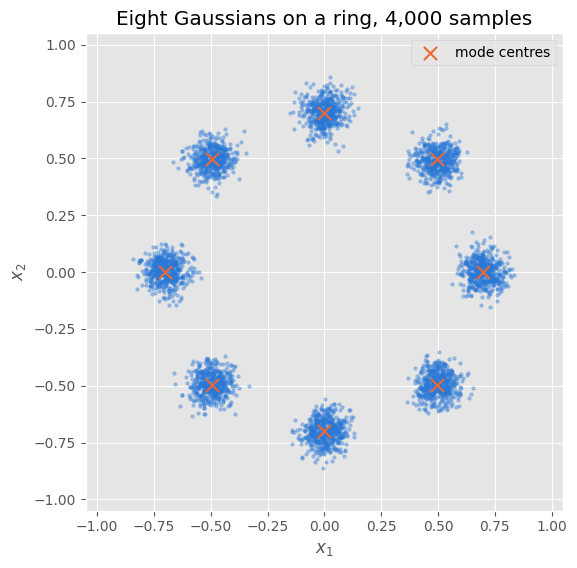

In [13]:
n_modes, ring_radius, ring_spread = 8, 0.7, 0.05
mode_angles = 2 * np.pi * np.arange(n_modes) / n_modes
mode_centres = np.stack([ring_radius * np.cos(mode_angles),
                         ring_radius * np.sin(mode_angles)], axis=1)


def ring_samples(n, rng):
    which = rng.integers(0, n_modes, n)
    return mode_centres[which] + rng.normal(0, ring_spread, (n, 2))


def mode_stats(samples):
    # nearest centre for every sample, then how many samples are close enough to count
    d = np.linalg.norm(samples[:, None, :] - mode_centres[None, :, :], axis=2)
    nearest = d.argmin(axis=1)
    close = d.min(axis=1) < 3 * ring_spread
    counts = np.bincount(nearest[close], minlength=n_modes)
    p = counts / max(counts.sum(), 1)
    captured = int((counts >= 0.01 * len(samples)).sum())
    nz = p > 0
    kl = float(np.sum(p[nz] * np.log(p[nz] * n_modes)))
    return captured, float(close.mean()), kl, counts


X_ring = ring_samples(4000, np.random.default_rng(0))

print('ring data:', X_ring.shape, ' range', X_ring.min().round(3), 'to', X_ring.max().round(3))
print('mode statistics of the data itself:')
cap, inside, kl, counts = mode_stats(X_ring)
print(f'  modes captured {cap}/8   inside 3 sigma {inside:.3f}   KL from uniform {kl:.4f}')
print('  counts per mode', counts)

plt.figure(figsize=(6.2, 6.2))
plt.scatter(X_ring[:, 0], X_ring[:, 1], s=6, alpha=0.4, color=blue)
plt.scatter(mode_centres[:, 0], mode_centres[:, 1], s=90, marker='x', color=orange, label='mode centres')
plt.gca().set_aspect('equal')
plt.xlim(-1.05, 1.05)
plt.ylim(-1.05, 1.05)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Eight Gaussians on a ring, 4,000 samples')
plt.legend()
plt.show()

## The alternating loop

One epoch walks the 4,000 samples in batches of 128, and for each batch does one discriminator step
followed by one generator step:

1. Draw $\mathbf{z}_1 \dots \mathbf{z}_m \sim \mathcal{N}(0, I)$ and push them through $G$. Treat the
   result as fixed data.
2. Take a gradient step on $J_D$ using those samples and $m$ real ones. Only $D$ moves.
3. Draw a **fresh** batch of $\mathbf{z}$, push it through $G$ and then through $D$, and take a
   gradient step on $J_G^{\text{ns}}$. Only $G$ moves.

Step 3 uses new noise rather than the batch from step 1 because $D$ has changed in between, and the
generator should be scored by the discriminator it now faces.

The settings, chosen so the notebook runs quickly rather than to squeeze out the best possible
result: $\mathbf{z} \in \mathbb{R}^2$, generator $2 \to 64 \to 64 \to 2$ with $\tanh$ output,
discriminator $2 \to 64 \to 64 \to 1$, Adam at $4 \times 10^{-4}$ for both with
$\beta_1 = 0.5$, batches of 128, 600 epochs. That is 18,600 discriminator steps and 18,600 generator
steps, and it takes about ten seconds.

The latent dimension is 2, matching the data. It does not have to: a larger $\mathbf{z}$ works too,
and part of the point of the noise vector is that its dimension is a free choice. Two is used here so
that the map from noise to samples can be pictured as a warping of the plane.

In [14]:
gan_ring = Generative_Adversarial_Network(2, 2, [64, 64], [64, 64], g_output='tanh',
                                          g_lr=4e-4, d_lr=4e-4, seed=0)

print(f'generator     {gan_ring.G.layer_sizes}  parameters {gan_ring.G.parameter_count()}')
print(f'discriminator {gan_ring.D.layer_sizes}  parameters {gan_ring.D.parameter_count()}')
print()

start = time.time()
gan_ring.fit(X_ring, epochs=600, batch_size=128, seed=1,
             snapshot_every=25, snapshot_n=3000, report_every=100)
ring_time = time.time() - start

ring_samples_final = gan_ring.generate(4000, np.random.default_rng(5))
cap, inside, kl, counts = mode_stats(ring_samples_final)

print()
print(f'training time            : {ring_time:.1f} s')
print(f'modes captured           : {cap} of {n_modes}')
print(f'samples within 3 sigma   : {inside:.3f}')
print(f'KL of mode histogram     : {kl:.4f}   (0 is uniform, log 8 = {np.log(8):.4f} is total collapse)')
print(f'samples per mode         : {counts}')

generator     [2, 64, 64, 2]  parameters 4482
discriminator [2, 64, 64, 1]  parameters 4417



  epoch   100  D loss 1.2226  G loss 0.8348  D acc on real 0.742  on fake 0.610


  epoch   200  D loss 1.2371  G loss 0.9070  D acc on real 0.574  on fake 0.643


  epoch   300  D loss 1.2627  G loss 0.8873  D acc on real 0.606  on fake 0.572


  epoch   400  D loss 1.3049  G loss 0.8529  D acc on real 0.558  on fake 0.568


  epoch   500  D loss 1.2976  G loss 0.8304  D acc on real 0.623  on fake 0.516


  epoch   600  D loss 1.3033  G loss 0.8644  D acc on real 0.592  on fake 0.547

training time            : 9.6 s
modes captured           : 8 of 8
samples within 3 sigma   : 0.867
KL of mode histogram     : 0.0286   (0 is uniform, log 8 = 2.0794 is total collapse)
samples per mode         : [224 576 456 356 418 452 484 500]


The figure follows the same 3,000 noise vectors through training. Because the noise is fixed, a point
in one panel and the point in the same position in the next panel are the same $\mathbf{z}$, so the
panels show the generator's map deforming rather than eight independent samples.

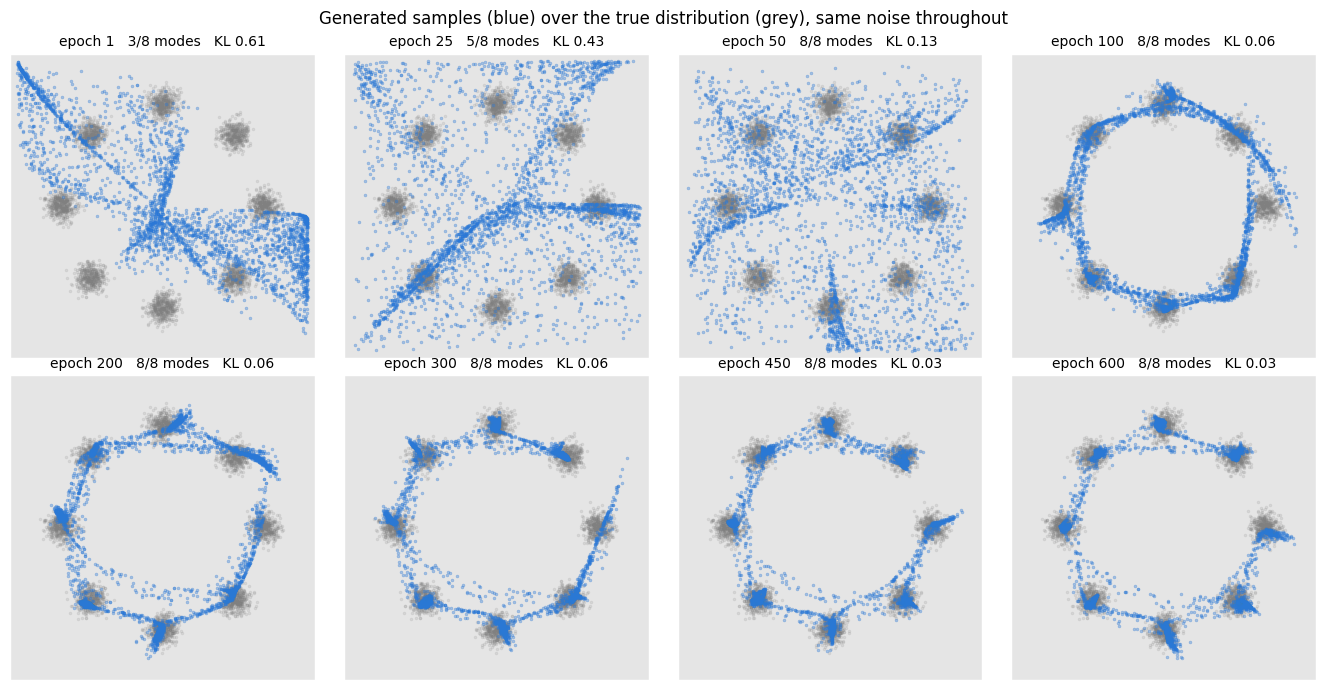

In [15]:
picks = [1, 25, 50, 100, 200, 300, 450, 600]
chosen = [s for s in gan_ring.snapshots if s[0] in picks]

fig, ax = plt.subplots(2, 4, figsize=(13.5, 7))

for a, (epoch, samples) in zip(ax.ravel(), chosen):
    a.scatter(X_ring[:, 0], X_ring[:, 1], s=4, alpha=0.15, color='grey')
    a.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.35, color=blue)
    cap_e, inside_e, kl_e, _ = mode_stats(samples)
    a.set_title(f'epoch {epoch}   {cap_e}/8 modes   KL {kl_e:.2f}', fontsize=10)
    a.set_xlim(-1.05, 1.05)
    a.set_ylim(-1.05, 1.05)
    a.set_aspect('equal')
    a.set_xticks([])
    a.set_yticks([])

plt.suptitle('Generated samples (blue) over the true distribution (grey), same noise throughout')
plt.tight_layout()
plt.show()

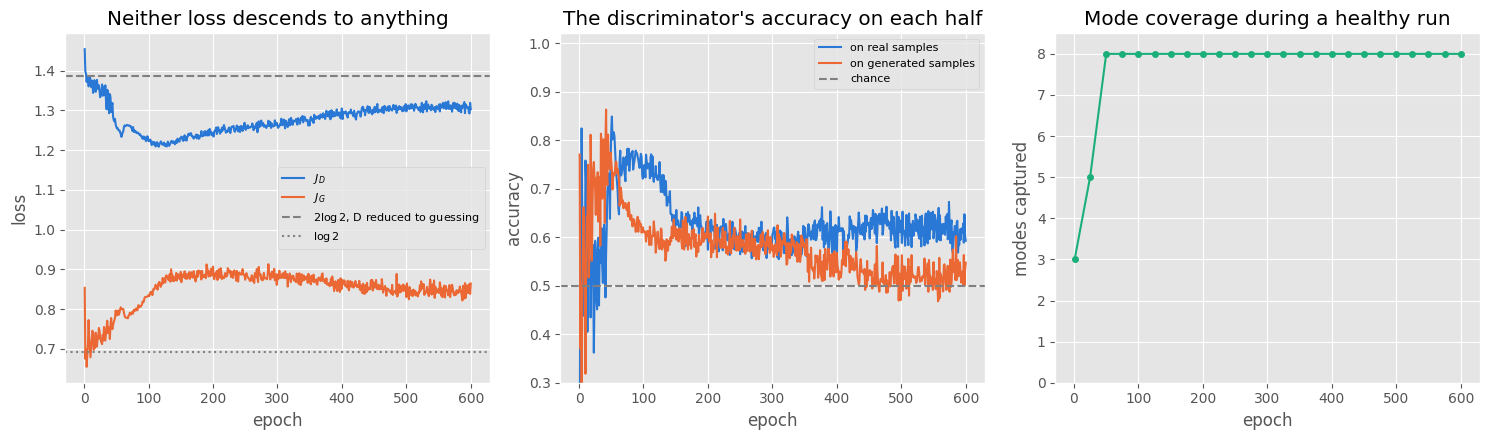

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
epochs_axis = np.arange(1, len(gan_ring.history['d_loss']) + 1)

ax[0].plot(epochs_axis, gan_ring.history['d_loss'], color=blue, label='$J_D$')
ax[0].plot(epochs_axis, gan_ring.history['g_loss'], color=orange, label='$J_G$')
ax[0].axhline(2 * np.log(2), color='grey', linestyle='--', label='$2\\log 2$, D reduced to guessing')
ax[0].axhline(np.log(2), color='grey', linestyle=':', label='$\\log 2$')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].set_title('Neither loss descends to anything')
ax[0].legend(fontsize=8)

ax[1].plot(epochs_axis, gan_ring.history['acc_real'], color=blue, label='on real samples')
ax[1].plot(epochs_axis, gan_ring.history['acc_fake'], color=orange, label='on generated samples')
ax[1].axhline(0.5, color='grey', linestyle='--', label='chance')
ax[1].set_ylim(0.3, 1.02)
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].set_title("The discriminator's accuracy on each half")
ax[1].legend(fontsize=8)

ax[2].plot([e for e, _ in gan_ring.snapshots],
           [mode_stats(s)[0] for _, s in gan_ring.snapshots], 'o-', color=green, markersize=4)
ax[2].set_ylim(0, 8.5)
ax[2].set_yticks(range(9))
ax[2].set_xlabel('epoch')
ax[2].set_ylabel('modes captured')
ax[2].set_title('Mode coverage during a healthy run')

plt.tight_layout()
plt.show()

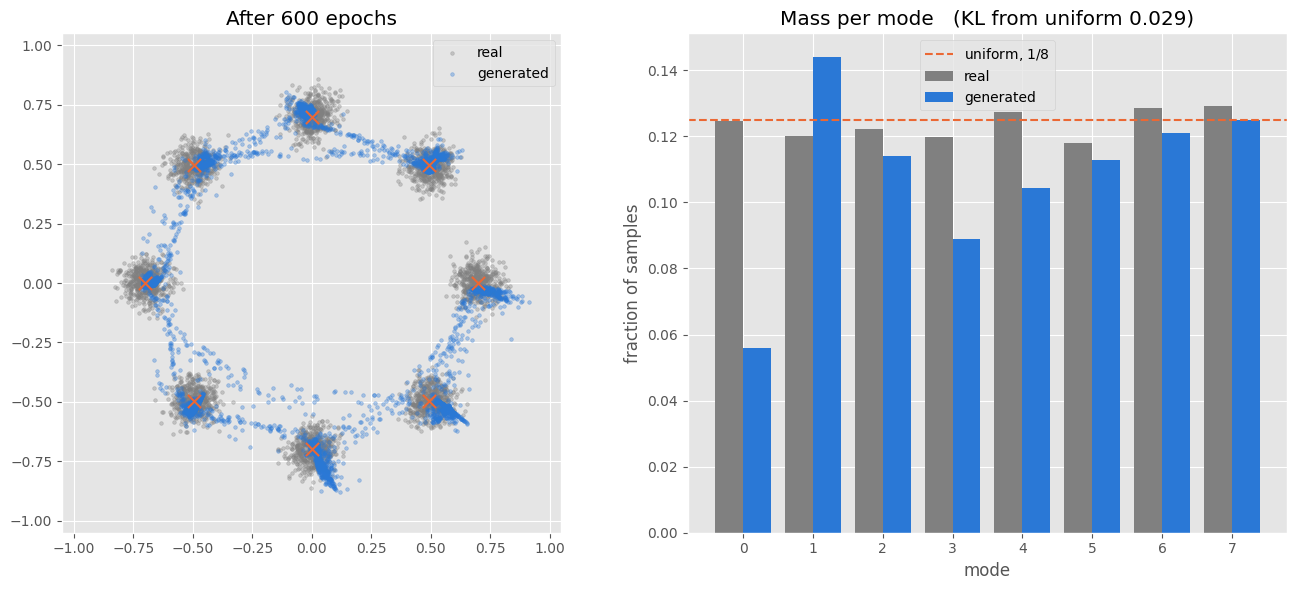

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 6))

ax[0].scatter(X_ring[:, 0], X_ring[:, 1], s=7, alpha=0.35, color='grey', label='real')
ax[0].scatter(ring_samples_final[:, 0], ring_samples_final[:, 1], s=7, alpha=0.35, color=blue,
              label='generated')
ax[0].scatter(mode_centres[:, 0], mode_centres[:, 1], s=90, marker='x', color=orange)
ax[0].set_aspect('equal')
ax[0].set_xlim(-1.05, 1.05)
ax[0].set_ylim(-1.05, 1.05)
ax[0].set_title(f'After {len(epochs_axis)} epochs')
ax[0].legend()

width = 0.4
positions = np.arange(n_modes)
ax[1].bar(positions - width / 2, mode_stats(X_ring)[3] / len(X_ring), width, color='grey', label='real')
ax[1].bar(positions + width / 2, counts / len(ring_samples_final), width, color=blue, label='generated')
ax[1].axhline(1 / n_modes, color=orange, linestyle='--', label='uniform, $1/8$')
ax[1].set_xticks(positions)
ax[1].set_xlabel('mode')
ax[1].set_ylabel('fraction of samples')
ax[1].set_title(f'Mass per mode   (KL from uniform {kl:.3f})')
ax[1].legend()

plt.tight_layout()
plt.show()

This is what a healthy run looks like, and none of it resembles a training curve from any other
notebook here.

- **The losses go nowhere.** $J_D$ stays in a narrow band a little below $2\log 2 \approx 1.386$ -
  down to 1.21 by epoch 120 and back up to 1.30 by the end - while $J_G$ does the mirror image, up
  from $\log 2 \approx 0.693$ to 0.89 and back to 0.85. Those are the values the two losses take when
  $D$ outputs $\tfrac12$ everywhere. Neither descends, and the net movement over 600 epochs is
  smaller than the movement over the first 100. Read as a loss curve this would look like a run that
  stalled immediately; it is the opposite.
- **The accuracies sit above chance but well short of certainty**, settling near 0.60 on real samples
  and 0.53 on generated ones. $D$ keeps a small edge over the generator without ever separating the
  two sets, which is the condition under which $\partial s/\partial\mathbf{x}$ is informative. A
  discriminator at 100% on both halves would mean the supports have come apart and the generator is
  learning nothing - which is exactly what the next section's first failure run does.
- **The only measurement that improves monotonically is mode coverage**, and it is computed from the
  samples, not from either loss. In a GAN the progress signal has to come from outside the objective.

The generated cloud reaches all eight modes and its per-mode mass is close to uniform. The clusters
are slightly fatter than the real ones and a thin bridge of samples runs between neighbouring modes -
the generator is a continuous map from a connected $\mathbb{R}^2$, so it cannot produce eight
disconnected blobs without stretching some of the noise across the gaps. Those bridge points are the
price of that continuity, and they are visible in every panel.

## Mode collapse

The generator's objective asks for samples that $D$ calls real. It does not ask for *variety*. If a
single output point fools the current discriminator, a generator that maps every $\mathbf{z}$ to that
one point scores perfectly on $J_G$, and nothing in the loss objects. The only force opposing it is
that $D$, seeing nothing but that point among the fakes, learns to reject it - after which the
generator moves to a different single point, and the cycle repeats without ever producing the whole
distribution.

Whether that happens is a question about the *balance* of the two learning processes, not about
either objective. Two unbalanced settings are run below against the same data and the same
architecture as the healthy run.

- **A discriminator that runs far ahead**: $D$ takes three steps per generator step at ten times the
  generator's learning rate. $D$ becomes confident quickly, the generator is left chasing whichever
  region is currently least well defended, and it abandons the rest.
- **A generator that runs far ahead**: $G$'s learning rate is 50 times $D$'s. The generator can move
  its whole output onto the single best-scoring point faster than $D$ can respond, and once every
  $\mathbf{z}$ maps to the same place there is no gradient pointing back towards diversity - the
  generated cloud has no spread left to grow from.

Neither is a trick played on the algorithm. Both are learning-rate choices of the kind that would be
unremarkable in any other notebook here, and that is the point: the objective gives no warning.

In [18]:
collapse_runs = {}
start = time.time()

settings = [('healthy', dict(g_lr=4e-4, d_lr=4e-4), 1, 600),
            ('D runs ahead', dict(g_lr=2e-4, d_lr=4e-3), 3, 400),
            ('G runs ahead', dict(g_lr=1e-2, d_lr=2e-4), 1, 400)]

for name, lrs, d_steps, epochs in settings:
    if name == 'healthy':
        collapse_runs[name] = gan_ring
        continue
    gan = Generative_Adversarial_Network(2, 2, [64, 64], [64, 64], g_output='tanh', seed=0, **lrs)
    gan.fit(X_ring, epochs=epochs, batch_size=128, seed=1, d_steps=d_steps,
            snapshot_every=25, snapshot_n=3000)
    collapse_runs[name] = gan

print(f'{"run":16s} {"epochs":>7s} {"D steps":>8s} {"g_lr":>8s} {"d_lr":>8s}'
      f' {"modes":>6s} {"inside":>8s} {"KL":>7s} {"D acc fake":>11s}')
for name, lrs, d_steps, epochs in settings:
    gan = collapse_runs[name]
    s = gan.generate(4000, np.random.default_rng(5))
    cap_n, inside_n, kl_n, counts_n = mode_stats(s)
    print(f'{name:16s} {len(gan.history["d_loss"]):7d} {d_steps:8d} {lrs["g_lr"]:8.1e}'
          f' {lrs["d_lr"]:8.1e} {cap_n:6d} {inside_n:8.3f} {kl_n:7.3f}'
          f' {gan.history["acc_fake"][-1]:11.3f}')
    print(f'{"":16s} samples per mode {counts_n}')

print()
print(f'total training time for the two failure runs: {time.time() - start:.1f} s')

run               epochs  D steps     g_lr     d_lr  modes   inside      KL  D acc fake
healthy              600        1  4.0e-04  4.0e-04      8    0.867   0.029       0.547
                 samples per mode [224 576 456 356 418 452 484 500]
D runs ahead         400        3  2.0e-04  4.0e-03      3    0.905   0.981       1.000
                 samples per mode [   0 1164 1241 1216    0    0    0    0]
G runs ahead         400        1  1.0e-02  2.0e-04      1    0.997   2.079       0.677
                 samples per mode [3986    0    0    0    0    0    0    0]

total training time for the two failure runs: 18.5 s


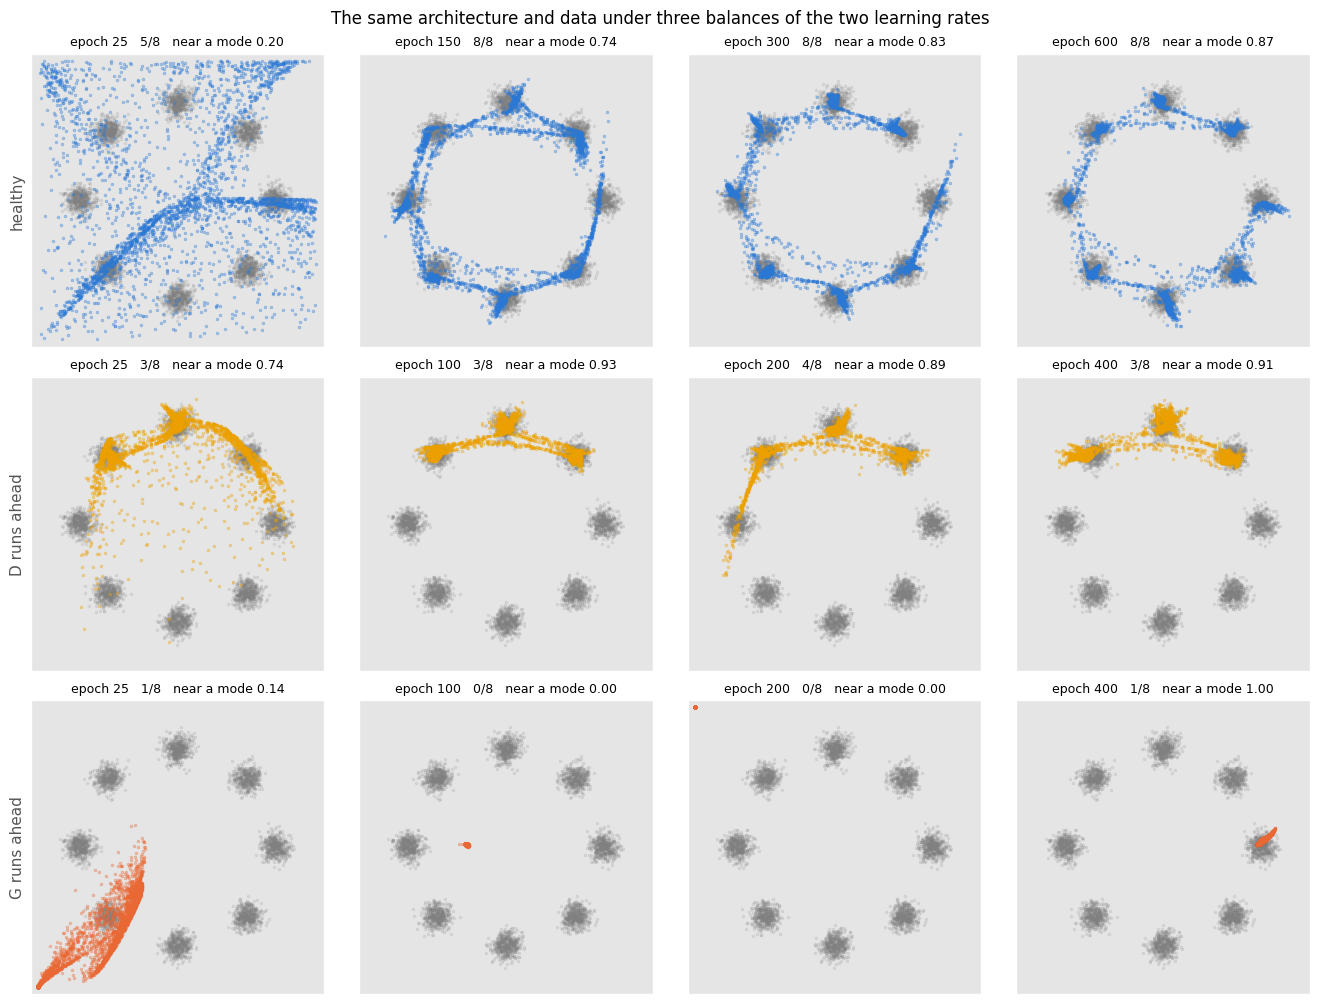

In [19]:
fig, ax = plt.subplots(3, 4, figsize=(13.5, 10.2))

for row, (name, _, _, epochs) in enumerate(settings):
    gan = collapse_runs[name]
    wanted = [25, epochs // 4, epochs // 2, epochs]
    chosen = [s for s in gan.snapshots if s[0] in wanted][:4]
    for col, (epoch, samples) in enumerate(chosen):
        a = ax[row, col]
        a.scatter(X_ring[:, 0], X_ring[:, 1], s=4, alpha=0.15, color='grey')
        a.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.35,
                  color=[blue, gold, orange][row])
        cap_e, inside_e, kl_e, _ = mode_stats(samples)
        a.set_title(f'epoch {epoch}   {cap_e}/8   near a mode {inside_e:.2f}', fontsize=9)
        a.set_xlim(-1.05, 1.05)
        a.set_ylim(-1.05, 1.05)
        a.set_aspect('equal')
        a.set_xticks([])
        a.set_yticks([])
    ax[row, 0].set_ylabel(name, fontsize=11)

plt.suptitle('The same architecture and data under three balances of the two learning rates')
plt.tight_layout()
plt.show()

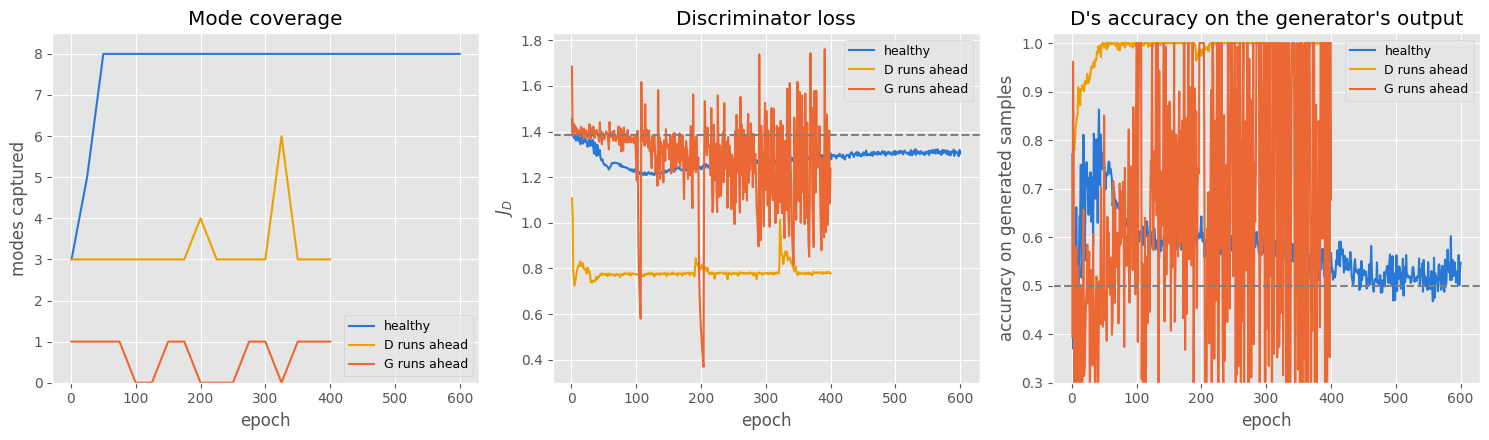

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

for (name, _, _, _), colour in zip(settings, [blue, gold, orange]):
    gan = collapse_runs[name]
    epochs_n = np.arange(1, len(gan.history['d_loss']) + 1)
    ax[0].plot([e for e, _ in gan.snapshots], [mode_stats(s)[0] for _, s in gan.snapshots],
               color=colour, label=name)
    ax[1].plot(epochs_n, gan.history['d_loss'], color=colour, label=name)
    ax[2].plot(epochs_n, gan.history['acc_fake'], color=colour, label=name)

ax[0].set_ylim(0, 8.5)
ax[0].set_yticks(range(9))
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('modes captured')
ax[0].set_title('Mode coverage')
ax[0].legend(fontsize=9)

ax[1].axhline(2 * np.log(2), color='grey', linestyle='--')
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('$J_D$')
ax[1].set_title('Discriminator loss')
ax[1].legend(fontsize=9)

ax[2].axhline(0.5, color='grey', linestyle='--')
ax[2].set_ylim(0.3, 1.02)
ax[2].set_xlabel('epoch')
ax[2].set_ylabel('accuracy on generated samples')
ax[2].set_title("D's accuracy on the generator's output")
ax[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

The two failures are different, and only one of them is visible in the losses.

**The generator running ahead collapses completely.** All 3,986 of its samples that land near any
mode land near the same one, giving a mode-histogram KL of 2.079, which is $\log 8$ to three
decimals - the maximum. The snapshots show what the mechanism actually looks like: the generated
cloud is a single small blob, and that blob is in a *different place* in every panel. It is not stuck.
$D$ learns to reject wherever the blob currently is, the generator relocates it somewhere else that
is briefly undefended, and the pair cycles. In two of the four panels the blob is not within
$3\sigma$ of any mode at all, which is why those read 0/8 rather than 1/8.

That run's discriminator loss is the instructive part. Its *average level* is no worse than the
healthy run's - it oscillates around the same band rather than sitting below it - so a reader
watching only $J_D$ would see violent noise and no clear verdict. The failure is obvious in the
samples and equivocal in the objective, which is why the mode-coverage panel is computed from the
samples at all.

**The discriminator running ahead fails differently**, and here the loss does give it away. $J_D$
settles at about 0.78, far below the healthy run's 1.30, and $D$'s accuracy on generated samples
pins at 1.000: it is separating the two sets perfectly. That is precisely the disjoint-support
situation from the derivation of $D^\star$ - the Jensen-Shannon divergence is stuck at its maximum
and carries no direction - and the generator, given nothing to work with, holds three of the eight
modes and never finds the other five. This partial version is the more common outcome in practice,
and it is the more dangerous one: the three modes it does produce look perfectly good, so judged on
sample quality alone it would pass.

## Non-convergence in the smallest possible GAN

Mode collapse is a failure of what the equilibrium is. Non-convergence is a failure of getting there
at all, and it can be shown exactly rather than empirically by shrinking the problem until both
networks have one parameter each.

Let the data be a single point, $p_{\text{data}} = \delta_0$. Let the generator have one parameter
$\theta$ and always output $\theta$, so $p_g = \delta_\theta$. Let the discriminator have one
parameter $\psi$ and logit $s(x) = \psi x$, so $D(x) = \sigma(\psi x)$. The equilibrium is
$\theta = 0$ - the generator sits on the data - with $\psi = 0$, at which $D \equiv \tfrac12$.

The objective evaluates in closed form:

$$V(\theta, \psi) = \log \sigma(0) + \log\left(1 - \sigma(\psi\theta)\right)
= -\log 2 - \operatorname{softplus}(\psi\theta)$$

Both players' gradients follow immediately, using
$\frac{d}{du}\operatorname{softplus}(u) = \sigma(u)$:

$$\frac{\partial V}{\partial \psi} = -\sigma(\psi\theta)\,\theta,
\qquad
\frac{\partial J_G^{\text{sat}}}{\partial \theta} = -\sigma(\psi\theta)\,\psi,
\qquad
\frac{\partial J_G^{\text{ns}}}{\partial \theta} = -\sigma(-\psi\theta)\,\psi$$

Take the minimax version first and write $c = \sigma(\psi\theta) > 0$. Simultaneous gradient steps -
$D$ ascending $V$, $G$ descending $J_G$ - give

$$\dot\theta = c\,\psi, \qquad \dot\psi = -c\,\theta$$

which is a **rotation** about the origin, at a speed that varies with position but always
perpendicular to the radius. In continuous time $\theta^2 + \psi^2$ is exactly conserved: the pair
orbits the equilibrium forever and never approaches it. Discretising with a finite step size makes it
worse, because an Euler step on a rotation moves along the tangent and lands outside the circle it
started on, so the radius grows every step.

Nothing here is a defect of the networks - there is only one parameter each, the objective is
available in closed form, and the equilibrium is a single known point. It is the simultaneous descent
of two coupled objectives that fails.

The cell simulates both generator losses from the same starting point.

In [21]:
def dirac_gan(theta, psi, lr, steps, saturating):
    path = np.empty((steps + 1, 2))
    path[0] = (theta, psi)

    for t in range(steps):
        c = 1.0 / (1.0 + np.exp(-psi * theta))                  # sigma(psi * theta) = D(theta)
        grad_psi = -c * theta                                   # dV/dpsi, ascended by D
        grad_theta = -c * psi if saturating else -(1 - c) * psi  # dJ_G/dtheta, descended by G
        theta, psi = theta - lr * grad_theta, psi + lr * grad_psi
        path[t + 1] = (theta, psi)

    return path


paths = {name: dirac_gan(1.0, 1.0, 0.1, 4000, sat)
         for name, sat in [('minimax', True), ('non-saturating', False)]}

print(f'{"loss":16s} {"radius at step":>16s} {"0":>8s} {"500":>8s} {"2000":>8s} {"4000":>8s}'
      f' {"sign changes in theta":>23s}')
for name, path in paths.items():
    r = np.hypot(path[:, 0], path[:, 1])
    flips = int((np.diff(np.sign(path[:, 0])) != 0).sum())
    print(f'{name:16s} {"":16s} {r[0]:8.4f} {r[500]:8.4f} {r[2000]:8.4f} {r[4000]:8.4f} {flips:23d}')

print()
print('final (theta, psi), and how fast each is still moving:')
for name, path in paths.items():
    step_size = np.hypot(*np.diff(path, axis=0).T)
    r = np.hypot(path[:, 0], path[:, 1])
    print(f'  {name:16s} theta {path[-1, 0]: .5f}   psi {path[-1, 1]: .5f}'
          f'   |theta| never below {np.abs(path[2000:, 0]).min():.5f} after step 2000')
    print(f'  {"":16s} step size {step_size[100]:.5f} at step 100 -> {step_size[-1]:.5f} at step 4000'
          f'   radius gained over the last 1000 steps {r[-1] - r[-1001]:+.4f}')

loss               radius at step        0      500     2000     4000   sign changes in theta
minimax                             1.4142   2.1793   3.2254   3.4892                      11
non-saturating                      1.4142   0.5211   0.4508   0.4446                      63

final (theta, psi), and how fast each is still moving:
  minimax          theta -2.48468   psi  2.44962   |theta| never below 0.03544 after step 2000
                   step size 0.03927 at step 100 -> 0.00079 at step 4000   radius gained over the last 1000 steps +0.0002
  non-saturating   theta -0.11867   psi  0.42843   |theta| never below 0.00018 after step 2000
                   step size 0.04341 at step 100 -> 0.02275 at step 4000   radius gained over the last 1000 steps -0.0025


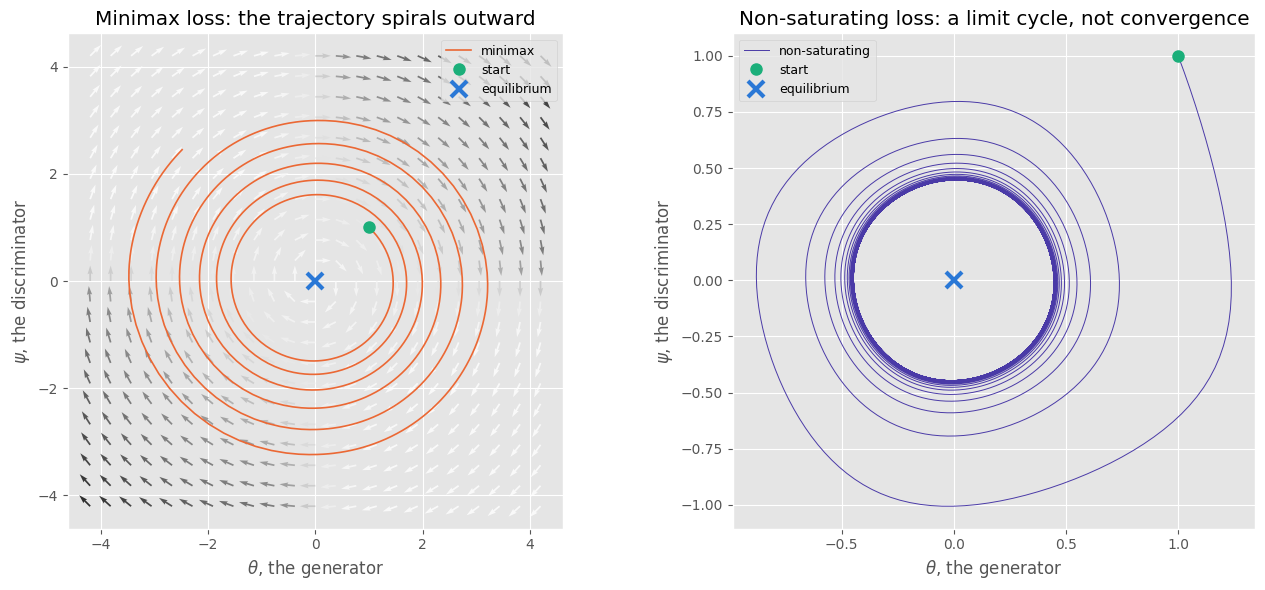

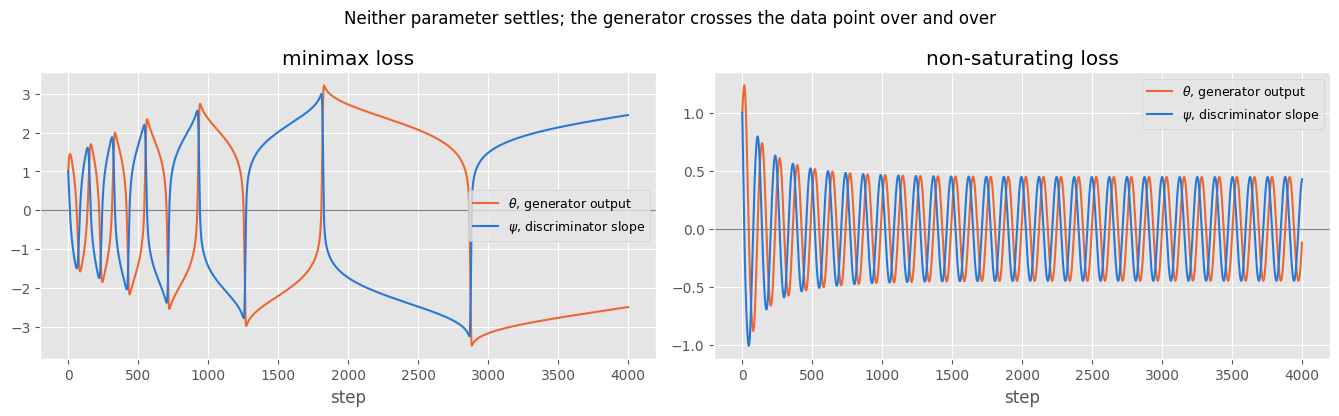

In [22]:
span = np.linspace(-4.2, 4.2, 23)
TH, PS = np.meshgrid(span, span)
C = 1.0 / (1.0 + np.exp(-PS * TH))
U, W = C * PS, -C * TH
mag = np.hypot(U, W) + 1e-12

fig, ax = plt.subplots(1, 2, figsize=(13.5, 6))

ax[0].quiver(TH, PS, U / mag, W / mag, mag, cmap='Greys', scale=32, width=0.0035, alpha=0.8)
ax[0].plot(paths['minimax'][:, 0], paths['minimax'][:, 1], color=orange, linewidth=1.2,
           label='minimax')
ax[0].plot(1.0, 1.0, 'o', color=green, markersize=8, label='start')
ax[0].plot(0, 0, 'x', color=blue, markersize=12, markeredgewidth=3, label='equilibrium')
ax[0].set_xlabel(r'$\theta$, the generator')
ax[0].set_ylabel(r'$\psi$, the discriminator')
ax[0].set_title('Minimax loss: the trajectory spirals outward')
ax[0].set_aspect('equal')
ax[0].legend(fontsize=9)

ax[1].plot(paths['non-saturating'][:, 0], paths['non-saturating'][:, 1], color=purple,
           linewidth=0.7, label='non-saturating')
ax[1].plot(1.0, 1.0, 'o', color=green, markersize=8, label='start')
ax[1].plot(0, 0, 'x', color=blue, markersize=12, markeredgewidth=3, label='equilibrium')
ax[1].set_xlabel(r'$\theta$, the generator')
ax[1].set_ylabel(r'$\psi$, the discriminator')
ax[1].set_title('Non-saturating loss: a limit cycle, not convergence')
ax[1].set_aspect('equal')
ax[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
for a, (name, path) in zip(ax, paths.items()):
    a.plot(path[:, 0], color=orange, label=r'$\theta$, generator output')
    a.plot(path[:, 1], color=blue, label=r'$\psi$, discriminator slope')
    a.axhline(0, color='grey', linewidth=0.8)
    a.set_xlabel('step')
    a.set_title(f'{name} loss')
    a.legend(fontsize=9)
plt.suptitle('Neither parameter settles; the generator crosses the data point over and over')
plt.tight_layout()
plt.show()

The two losses fail differently and both fail.

Under the **minimax** loss the trajectory spirals outward exactly as the rotation argument predicts,
from radius 1.41 to 3.49, and then grinds to a halt. It has not converged: it has saturated. Every
update carries the shared factor $c = \sigma(\psi\theta)$, and by the end $\psi\theta \approx -6.1$,
so $c \approx 0.002$. The step size falls from 0.039 early on to 0.0008, a slowdown of fifty times,
and the last thousand steps gain 0.0002 of radius between them. The pair is stalled at
$\theta = -2.48$, with the generator's single output nowhere near the data point at 0 and no
meaningful gradient left to move it. This is the vanishing gradient of the earlier section, appearing
in a model small enough to watch in full.

Under the **non-saturating** loss the trajectory does not stall - the factor $1 - \sigma(\psi\theta)$
keeps the generator moving - but it does not converge either. It spirals *inward* from radius 1.41
and then settles onto a closed orbit of radius 0.44 and circles it indefinitely, crossing
$\theta = 0$ sixty-three times in 4,000 steps without ever stopping there. The generator passes
through the correct answer over and over and keeps going, because at the moment it is right the
discriminator is not, and vice versa.

So the non-saturating loss is not a fix for non-convergence. It fixes the vanishing gradient, and
what is left over is the orbiting, which is visible in every GAN loss curve in this notebook as the
wobble that never settles. The whole family of later methods aimed at this - averaging the generator's
weights, penalising the gradient of $D$, using a different divergence - exists because simultaneous
gradient descent on a saddle point does not converge on its own.

## Handwritten digits

The toy distribution answers the questions about coverage. A real dataset answers a different one:
whether a hand-written NumPy GAN can produce anything recognisable at all.

`fetch_ucirepo(id=80)` gives the 5,620 handwritten digits used by `mlp_from_scratch.ipynb`,
`2d_cnn_from_scratch.ipynb` and `autoencoder_from_scratch.ipynb` - 8x8 images, pixel values 0 to 16,
divided by 16 to land in $[0, 1]$. They suit this notebook for two reasons beyond continuity with the
rest of the repository. At 64 dimensions the networks stay small enough to train in pure NumPy in
under a minute, and at 8x8 a digit is still legible, so the samples can be judged by eye without any
of the machinery an image quality score would need.

The generator's output layer is a sigmoid, matching the pixel range. Nothing else changes: the same
two classes, the same alternating loop, the same non-saturating loss. Labels are not used in training
and appear only in the final measurement.

digits: (5620, 64)  pixel range 0.0 to 1.0
training split: (4496, 64)
class counts  : [444 454 447 473 436 458 437 453 454 440]


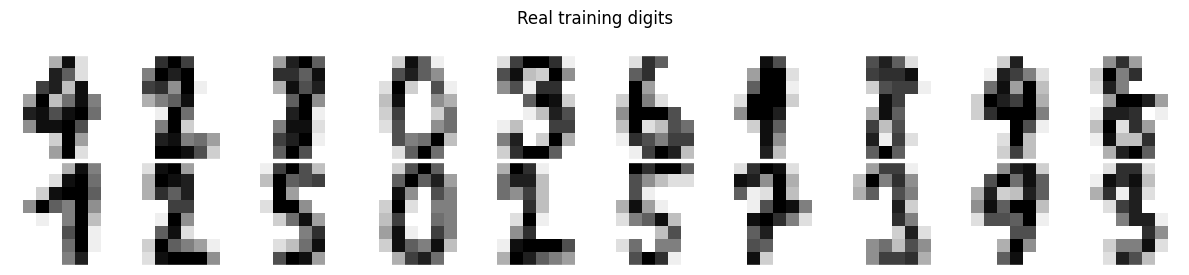

In [23]:
digits = fetch_ucirepo(id=80)

X_all = digits.data.features.values.astype(float) / 16.0
y_all = digits.data.targets.values.ravel()

rng = np.random.default_rng(0)
order = rng.permutation(len(X_all))
split = int(0.8 * len(X_all))

X_digits, y_digits = X_all[order[:split]], y_all[order[:split]]

print('digits:', X_all.shape, ' pixel range', X_all.min(), 'to', X_all.max())
print('training split:', X_digits.shape)
print('class counts  :', np.bincount(y_digits))

fig, ax = plt.subplots(2, 10, figsize=(12, 2.8))
for a, i in zip(ax.ravel(), range(20)):
    a.imshow(X_digits[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)
plt.suptitle('Real training digits')
plt.tight_layout()
plt.show()

In [24]:
gan_digits = Generative_Adversarial_Network(64, 24, [128, 256], [256, 128], g_output='sigmoid',
                                            g_lr=2e-4, d_lr=2e-4, seed=0)

print(f'generator     {gan_digits.G.layer_sizes}  parameters {gan_digits.G.parameter_count()}')
print(f'discriminator {gan_digits.D.layer_sizes}  parameters {gan_digits.D.parameter_count()}')
print()

start = time.time()
gan_digits.fit(X_digits, epochs=300, batch_size=64, seed=1,
               snapshot_every=25, snapshot_n=64, snapshot_seed=42, report_every=50)
digit_time = time.time() - start

print()
print(f'training time: {digit_time:.1f} s'
      f'   ({300 * (len(X_digits) // 64)} steps of each network)')

generator     [24, 128, 256, 64]  parameters 52672
discriminator [64, 256, 128, 1]  parameters 49665



  epoch    50  D loss 1.1821  G loss 0.8904  D acc on real 0.659  on fake 0.757


  epoch   100  D loss 1.1256  G loss 0.9614  D acc on real 0.686  on fake 0.769


  epoch   150  D loss 1.0984  G loss 1.0027  D acc on real 0.696  on fake 0.763


  epoch   200  D loss 1.0879  G loss 1.0571  D acc on real 0.684  on fake 0.763


  epoch   250  D loss 1.0645  G loss 1.0860  D acc on real 0.703  on fake 0.774


  epoch   300  D loss 1.0450  G loss 1.1037  D acc on real 0.712  on fake 0.781

training time: 22.9 s   (21000 steps of each network)


The same 64 noise vectors decoded at eight points during training. Reading down a column follows one
$\mathbf{z}$ as the generator's map changes under it.

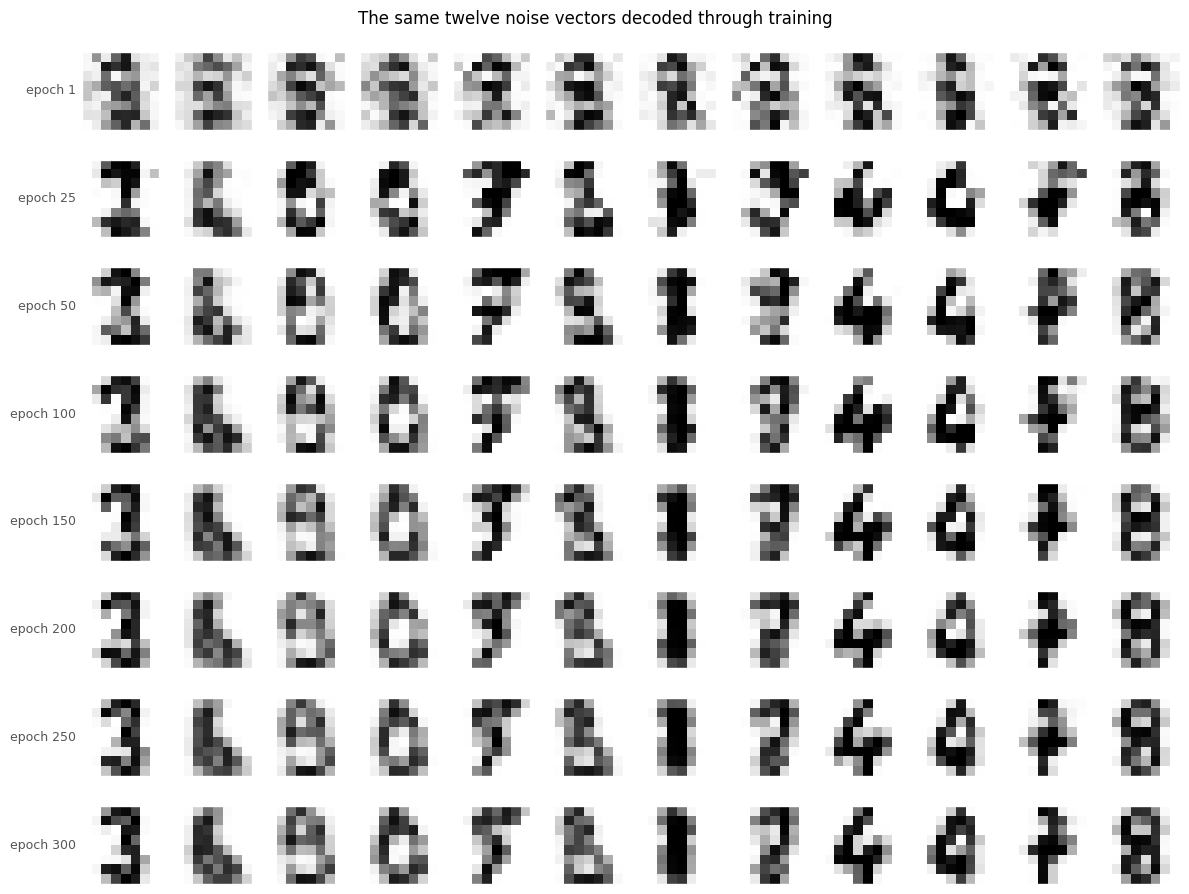

In [25]:
wanted = [1, 25, 50, 100, 150, 200, 250, 300]
rows = [s for s in gan_digits.snapshots if s[0] in wanted]

fig, ax = plt.subplots(len(rows), 12, figsize=(12, 1.15 * len(rows)))

for row, (epoch, samples) in enumerate(rows):
    for col in range(12):
        a = ax[row, col]
        a.imshow(samples[col].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
        a.set_xticks([])
        a.set_yticks([])
        a.grid(False)
        if col == 0:
            a.set_ylabel(f'epoch {epoch}', rotation=0, ha='right', va='center', fontsize=9)

plt.suptitle('The same twelve noise vectors decoded through training')
plt.tight_layout()
plt.show()

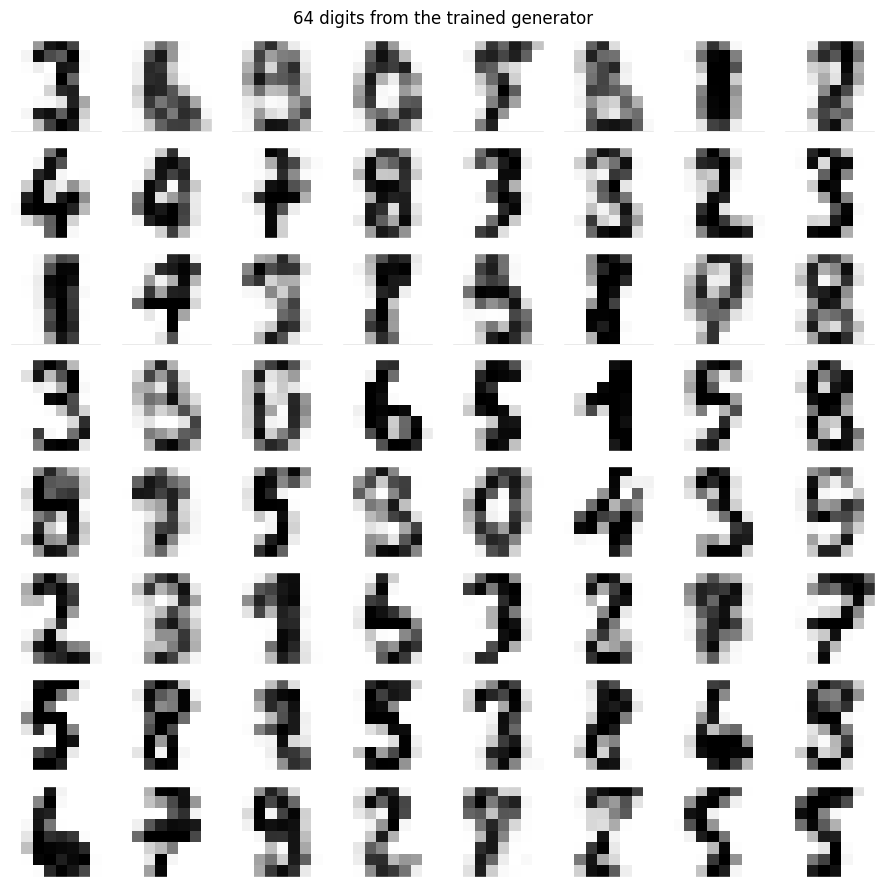

In [26]:
final_digits = gan_digits.generate(64, np.random.default_rng(42))

fig, ax = plt.subplots(8, 8, figsize=(9, 9))
for a, image in zip(ax.ravel(), final_digits):
    a.imshow(image.reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    a.set_xticks([])
    a.set_yticks([])
    a.grid(False)
plt.suptitle('64 digits from the trained generator')
plt.tight_layout()
plt.show()

## Is it copying the training set

A generator that memorised a few training images would produce convincing samples and would have
learned nothing. The check below is direct: for each generated digit, find the nearest training digit
in Euclidean pixel distance and draw the pair. For scale, the same statistic is computed for real
held-out digits, whose nearest training neighbour is a different image of the same digit written by a
different person, and for the training images themselves, whose nearest neighbour is excluded from
being themselves.

If the generator were copying, its distances would fall near zero and well below the held-out figure.

set                                  mean distance    median   minimum
generated digits                            1.1535    1.1468    0.4801
held-out real digits                        0.9802    0.9652    0.4719
training digits (self excluded)             0.9888    0.9642    0.4961

pixel statistics    generated mean 0.3059 std 0.3749
                    real      mean 0.3068 std 0.3768


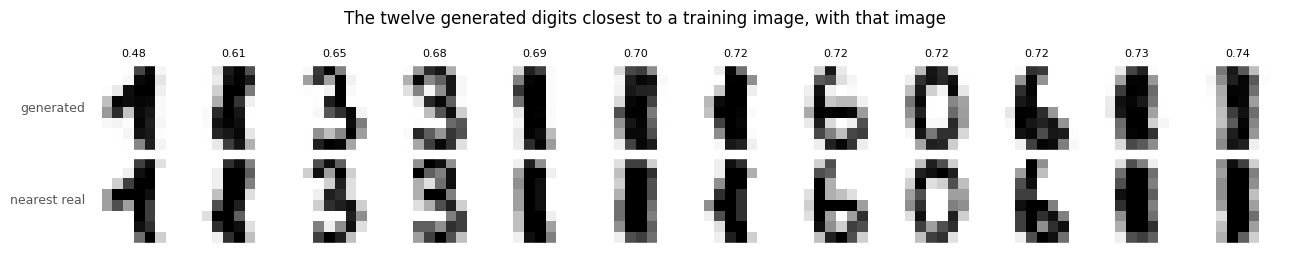

In [27]:
sample_pool = gan_digits.generate(500, np.random.default_rng(11))
held_out = X_all[order[split:]][:500]


def nearest_training(Q, exclude_self=False):
    sq_q = (Q ** 2).sum(axis=1)[:, None]
    sq_x = (X_digits ** 2).sum(axis=1)[None, :]
    d = np.maximum(sq_q + sq_x - 2 * (Q @ X_digits.T), 0)
    if exclude_self:
        np.fill_diagonal(d, np.inf)
    return np.sqrt(d.min(axis=1)), d.argmin(axis=1)


gen_dist, gen_match = nearest_training(sample_pool)
test_dist, _ = nearest_training(held_out)
train_dist, _ = nearest_training(X_digits[:500], exclude_self=True)

print(f'{"set":34s} {"mean distance":>15s} {"median":>9s} {"minimum":>9s}')
print(f'{"generated digits":34s} {gen_dist.mean():15.4f} {np.median(gen_dist):9.4f} {gen_dist.min():9.4f}')
print(f'{"held-out real digits":34s} {test_dist.mean():15.4f} {np.median(test_dist):9.4f} {test_dist.min():9.4f}')
print(f'{"training digits (self excluded)":34s} {train_dist.mean():15.4f} {np.median(train_dist):9.4f} {train_dist.min():9.4f}')
print()
print(f'pixel statistics    generated mean {sample_pool.mean():.4f} std {sample_pool.std():.4f}')
print(f'                    real      mean {X_digits.mean():.4f} std {X_digits.std():.4f}')

closest = np.argsort(gen_dist)[:12]

fig, ax = plt.subplots(2, 12, figsize=(13, 2.6))
for col, i in enumerate(closest):
    ax[0, col].imshow(sample_pool[i].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    ax[1, col].imshow(X_digits[gen_match[i]].reshape(8, 8), cmap='gray_r', vmin=0, vmax=1)
    ax[0, col].set_title(f'{gen_dist[i]:.2f}', fontsize=8)
    for row in range(2):
        ax[row, col].set_xticks([])
        ax[row, col].set_yticks([])
        ax[row, col].grid(False)
ax[0, 0].set_ylabel('generated', rotation=0, ha='right', va='center', fontsize=9)
ax[1, 0].set_ylabel('nearest real', rotation=0, ha='right', va='center', fontsize=9)
plt.suptitle('The twelve generated digits closest to a training image, with that image')
plt.tight_layout()
plt.show()

The generated digits sit *further* from their nearest training image than held-out real digits do -
1.153 against 0.980 on average, and 1.147 against 0.965 at the median. Held-out digits set the scale
here: their nearest training neighbour is the same digit written by someone else, at a distance of
about 0.98, and the training images themselves are no closer to each other than that. A generator
that had memorised would produce distances at or below the held-out figure and a minimum near zero;
these are above it throughout, with a minimum of 0.480 that is no smaller than the closest pair of
distinct real digits. The generator is producing images near the data rather than images from it,
and paying for the near-miss with a little extra blur, which is what the figure shows: the closest
matches are recognisably the same digit as their neighbour, not the same image.

## Class coverage and training curves

The ring gave mode coverage directly because the modes were known. For digits the analogue uses the
labels, for the first and only time: each generated image is assigned the label of its nearest
training digit, and the resulting histogram over the ten classes is compared against the real class
distribution. It is a crude measure - a badly formed image still gets assigned to whichever digit it
is least unlike - but it detects the failure that matters, a generator that has quietly stopped
producing some of the digits.

classes reaching 1% of samples : 10 of 10
KL(generated || real) over classes: 0.0790

 digit     real   generated
     0   0.0988      0.0500
     1   0.1010      0.1035
     2   0.0994      0.0590
     3   0.1052      0.1800
     4   0.0970      0.0615
     5   0.1019      0.1280
     6   0.0972      0.0840
     7   0.1008      0.0615
     8   0.1010      0.1420
     9   0.0979      0.1305


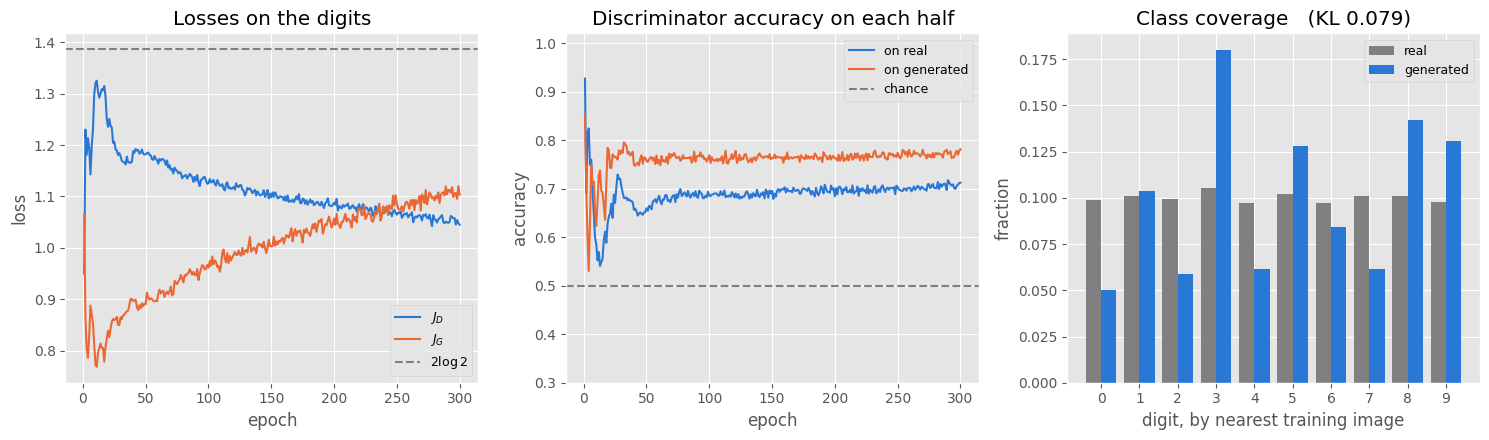

In [28]:
big_sample = gan_digits.generate(2000, np.random.default_rng(13))
_, match = nearest_training(big_sample)
gen_labels = y_digits[match]

gen_hist = np.bincount(gen_labels, minlength=10) / len(gen_labels)
real_hist = np.bincount(y_digits, minlength=10) / len(y_digits)
kl_digits = float(np.sum(gen_hist[gen_hist > 0] * np.log(gen_hist[gen_hist > 0] / real_hist[gen_hist > 0])))

print(f'classes reaching 1% of samples : {(gen_hist >= 0.01).sum()} of 10')
print(f'KL(generated || real) over classes: {kl_digits:.4f}')
print()
print(f'{"digit":>6s} {"real":>8s} {"generated":>11s}')
for d in range(10):
    print(f'{d:6d} {real_hist[d]:8.4f} {gen_hist[d]:11.4f}')

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
epochs_axis = np.arange(1, len(gan_digits.history['d_loss']) + 1)

ax[0].plot(epochs_axis, gan_digits.history['d_loss'], color=blue, label='$J_D$')
ax[0].plot(epochs_axis, gan_digits.history['g_loss'], color=orange, label='$J_G$')
ax[0].axhline(2 * np.log(2), color='grey', linestyle='--', label='$2\\log 2$')
ax[0].set_xlabel('epoch')
ax[0].set_ylabel('loss')
ax[0].set_title('Losses on the digits')
ax[0].legend(fontsize=9)

ax[1].plot(epochs_axis, gan_digits.history['acc_real'], color=blue, label='on real')
ax[1].plot(epochs_axis, gan_digits.history['acc_fake'], color=orange, label='on generated')
ax[1].axhline(0.5, color='grey', linestyle='--', label='chance')
ax[1].set_ylim(0.3, 1.02)
ax[1].set_xlabel('epoch')
ax[1].set_ylabel('accuracy')
ax[1].set_title("Discriminator accuracy on each half")
ax[1].legend(fontsize=9)

width = 0.4
positions = np.arange(10)
ax[2].bar(positions - width / 2, real_hist, width, color='grey', label='real')
ax[2].bar(positions + width / 2, gen_hist, width, color=blue, label='generated')
ax[2].set_xticks(positions)
ax[2].set_xlabel('digit, by nearest training image')
ax[2].set_ylabel('fraction')
ax[2].set_title(f'Class coverage   (KL {kl_digits:.3f})')
ax[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

All ten digits are produced: every class reaches at least 1% of the samples, and the histogram's KL
from the real class distribution is 0.079. It is not uniform, though, and the departures are worth
reading rather than rounding off. Threes take 18.0% of the generated mass against 10.5% of the real,
eights 14.2% against 10.1% and nines 13.1% against 9.8%, while zeros take 5.0% against 9.9%, fours
6.2% against 9.7% and sevens 6.2% against 10.1%. That is a mild, unmistakable version of the same
pressure the ring made stark: the generator is over-producing the digits it finds easy and
under-producing the ones it does not, and nothing in $J_G$ objects, because a surplus of threes costs
it nothing as long as each three is convincing. This is what partial mode collapse looks like on real
data, and it is only detectable because the labels were available to count with. On a dataset without
labels it would be invisible.

The discriminator's accuracy curves say the run stayed healthy: about 0.71 on real and 0.78 on
generated at the end, above chance and nowhere near the 1.000 that flagged the failed ring run.

## Summary

In [29]:
cap_h, inside_h, kl_h, _ = mode_stats(collapse_runs['healthy'].generate(4000, np.random.default_rng(5)))

print(f'{"experiment":34s} {"result":>28s}')
print(f'{"worst gradient-check difference":34s} {max(worst_d, worst_g):28.2e}')
print(f'{"V(D*, G) two ways, gap":34s} {abs(game_value(D_star) - (2 * js - np.log(4))):28.2e}')
print(f'{"learned D vs analytic D*, max gap":34s} {np.abs(learned - D_star)[support].max():28.4f}')
print(f'{"ring, healthy: modes captured":34s} {f"{cap_h}/8":>28s}')
print(f'{"ring, healthy: mode-histogram KL":34s} {kl_h:28.4f}')
for name, _, _, _ in settings[1:]:
    c, _, k, _ = mode_stats(collapse_runs[name].generate(4000, np.random.default_rng(5)))
    print(f'{"ring, " + name + ": modes / KL":34s} {f"{c}/8   {k:.3f}":>28s}')
print(f'{"digits: classes at 1% or more":34s} {f"{(gen_hist >= 0.01).sum()}/10":>28s}')
print(f'{"digits: class-histogram KL":34s} {kl_digits:28.4f}')
print(f'{"digits: nearest-real distance":34s} {f"{gen_dist.mean():.3f} vs {test_dist.mean():.3f} real":>28s}')
print()
print(f'total notebook runtime: {time.time() - notebook_start:.1f} s')

experiment                                               result
worst gradient-check difference                        3.37e-11
V(D*, G) two ways, gap                                 8.50e-08
learned D vs analytic D*, max gap                        0.1255
ring, healthy: modes captured                               8/8
ring, healthy: mode-histogram KL                         0.0286
ring, D runs ahead: modes / KL                      3/8   0.981
ring, G runs ahead: modes / KL                      1/8   2.079
digits: classes at 1% or more                             10/10
digits: class-histogram KL                               0.0790
digits: nearest-real distance               1.153 vs 0.980 real

total notebook runtime: 64.7 s


- A GAN trains two networks on opposing objectives,
  $\min_G \max_D V(D,G) = \mathbb{E}_{p_{\text{data}}}[\log D(\mathbf{x})] +
  \mathbb{E}_{p_z}[\log(1 - D(G(\mathbf{z})))]$. There is no scalar being descended, so "the loss
  went down" is not evidence of anything. Both losses in the healthy run above sit near the values
  they take when $D$ is reduced to guessing and stay there while the samples improve.
- For a fixed generator the optimal discriminator is the density ratio $D^\star =
  p_{\text{data}}/(p_{\text{data}} + p_g)$, obtained by maximising the integrand pointwise.
  Substituting it back gives $V(D^\star, G) = 2 D_{\mathrm{JS}}(p_{\text{data}} \Vert p_g) - \log 4$,
  so the generator is minimising a Jensen-Shannon divergence. Both identities are confirmed by
  quadrature, and a trained network recovers $D^\star$ over the region carrying data.
- When the two supports are disjoint, $D_{\mathrm{JS}}$ is pinned at $\log 2$ no matter how far apart
  the distributions are, so a perfect discriminator supplies no direction to move in.
- Writing $D = \sigma(s)$, the generator's gradient carries a factor $\partial J_G/\partial s$ that is
  $-D$ under the literal minimax loss and $-(1 - D)$ under the non-saturating $-\log D$. The direction
  is identical and the magnitudes differ by $(1 - D)/D$, which is confirmed to full precision on a
  single sample: the minimax gradient dies exactly when $D$ is winning and the generator has the most
  to learn.
- The discriminator's backward pass is ordinary binary cross-entropy, $\partial J_D/\partial s =
  (D - y)/m$. The generator's requires running the same recurrence one step past $D$'s first layer to
  obtain $\partial J_G/\partial \mathbf{x}$, which is the entire message the generator ever gets about
  the data. Both are checked against finite differences to nine decimals or better.
- Which parameters are frozen is structural, not a matter of care: the generator step computes
  discriminator gradients as a by-product and must discard them, since they are gradients of $J_G$ and
  applying them would move $D$ to help its opponent.
- **Mode collapse.** Nothing in $J_G$ rewards variety, so a generator mapping every $\mathbf{z}$ to
  one point that fools the current $D$ is scoring perfectly. Whether this happens is decided by the
  balance of the two learning rates, not by either objective, and it is invisible in the loss curves -
  only a measurement taken from the samples reveals it.
- **Non-convergence.** In the one-parameter Dirac GAN the minimax dynamics reduce exactly to
  $\dot\theta = c\psi$, $\dot\psi = -c\theta$, a rotation about the equilibrium: continuous time
  orbits it forever, discrete steps spiral outward and then freeze in saturation. The non-saturating
  loss removes the freezing and leaves a limit cycle. Neither converges, in a problem with one
  parameter per network and a closed-form objective.
- On 8x8 handwritten digits the same code produces legible digits covering all ten classes, from a
  generator that never sees an image - only the vector $\partial J_G/\partial \mathbf{x}$ handed back
  by a discriminator that does. Generated samples sit further from the nearest training image than
  held-out real digits do, so the samples are not copies.